<a href="https://colab.research.google.com/github/Sachin20010517/demand-forecasting-model/blob/main/smartstockflow_forecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Store Demand Forecasting
### Hybrid XGBoost + LSTM Ensemble — Production Notebook

| Item | Detail |
|---|---|
| **Target** | `Units Sold` (daily demand per store-product) |
| **Dataset** | 73,100 rows · 5 stores · 20 products · Jan 2022 – Jan 2024 |
| **Architecture** | XGBoost (tabular) + LSTM (temporal) → Ridge meta-learner |
| **Accuracy target** | ≥ 70% forecast accuracy (Weighted MAPE-based) |
| **Key feature** | `Demand Forecast` (upstream planning signal, pre-sales, valid input) |

---
### Sections
1. Environment Setup  
2. Data Loading & Profiling  
3. Exploratory Data Analysis  
4. Preprocessing Pipeline  
5. Feature Engineering  
6. Feature Selection  
7. Train / Validation / Test Split  
8. Baseline Models  
9. XGBoost + Cross-Validation  
10. LSTM Model  
11. Hybrid Ensemble (Ridge Stacking)  
12. Evaluation & Comparison  
13. SHAP Explainability  
14. Date-Range Recursive Forecaster  
15. Save Artefacts


---
## 1. Environment Setup

In [69]:
!pip install xgboost shap scikit-learn tensorflow pandas numpy matplotlib seaborn joblib -q

In [70]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)

SEED = 42
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

from sklearn.preprocessing     import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model      import Ridge, LinearRegression, Lasso
from sklearn.feature_selection import mutual_info_regression, f_regression
from sklearn.metrics           import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection   import TimeSeriesSplit
from xgboost                   import XGBRegressor
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import shap

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print('All libraries loaded.')

TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.2.2
All libraries loaded.


---
## 2. Data Loading & Profiling

In [71]:
# ── Configure dataset path ────────────────────────────────────────────────────
DATA_PATH = 'new-retail_store_inventory.csv'

df_raw = pd.read_csv(DATA_PATH)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

print('=' * 55)
print('DATASET PROFILE')
print('=' * 55)
print(f'  Rows          : {len(df_raw):,}')
print(f'  Columns       : {df_raw.shape[1]}')
print(f'  Date range    : {df_raw["Date"].min().date()}  to  {df_raw["Date"].max().date()}')
print(f'  Stores        : {df_raw["Store ID"].nunique()}  {list(df_raw["Store ID"].unique())}')
print(f'  Products      : {df_raw["Product ID"].nunique()}')
print(f'  Categories    : {list(df_raw["Category"].unique())}')
print(f'  Missing vals  : {df_raw.isnull().sum().sum()}')
print(f'  Duplicates    : {df_raw.duplicated().sum()}')
print('=' * 55)
df_raw.head()

DATASET PROFILE
  Rows          : 73,100
  Columns       : 16
  Date range    : 2022-01-01  to  2024-01-01
  Stores        : 5  ['S001', 'S002', 'S003', 'S004', 'S005']
  Products      : 20
  Categories    : ['Drinks', 'Confectionery', 'Snacks', 'Bakery & Bread', 'Dairy & Eggs', 'Grocery']
  Missing vals  : 0
  Duplicates    : 0


,Date,Store ID,Product ID,Product Name,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,PROD-001,Coca-Cola Original 330ml Can,Drinks,North,231,127,55,135.47,0.85,20,Rainy,0,0.9,Autumn
1,2022-01-01,S001,PROD-002,Pepsi Max 500ml Bottle,Drinks,South,204,150,66,144.04,1.05,20,Sunny,0,1.0,Autumn
2,2022-01-01,S001,PROD-003,Lucozade Energy Orange 380ml,Drinks,West,102,65,51,74.02,0.95,10,Sunny,1,0.9,Summer
3,2022-01-01,S001,PROD-004,Red Bull Energy Drink 250ml,Drinks,North,469,61,164,62.18,1.30,10,Cloudy,1,1.3,Autumn
4,2022-01-01,S001,PROD-005,Volvic Still Water 500ml,Drinks,East,166,14,135,9.26,0.65,0,Sunny,0,0.6,Summer


In [72]:
df_raw.info()
print()
df_raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Product Name        73100 non-null  object        
 4   Category            73100 non-null  object        
 5   Region              73100 non-null  object        
 6   Inventory Level     73100 non-null  int64         
 7   Units Sold          73100 non-null  int64         
 8   Units Ordered       73100 non-null  int64         
 9   Demand Forecast     73100 non-null  float64       
 10  Price               73100 non-null  float64       
 11  Discount            73100 non-null  int64         
 12  Weather Condition   73100 non-null  object        
 13  Holiday/Promotion   73100 non-null  int64     

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,1.083841,10.009508,0.497305,1.089559
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,0.550000,0.000000,0.000000,0.500000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,0.800000,5.000000,0.000000,0.750000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,0.950000,10.000000,0.000000,1.000000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,1.250000,15.000000,1.000000,1.250000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,2.350000,20.000000,1.000000,2.450000
std,NaN,129.949514,108.919406,52.277448,109.254076,0.418323,7.083746,0.499996,0.446199


In [73]:
print('Target  Units Sold  statistics:')
q1  = df_raw['Units Sold'].quantile(0.25)
q3  = df_raw['Units Sold'].quantile(0.75)
iqr = q3 - q1
outlier_pct = ((df_raw['Units Sold'] < q1 - 3*iqr) | (df_raw['Units Sold'] > q3 + 3*iqr)).mean() * 100
print(f'  Mean    : {df_raw["Units Sold"].mean():.1f}')
print(f'  Median  : {df_raw["Units Sold"].median():.1f}')
print(f'  Std dev : {df_raw["Units Sold"].std():.1f}')
print(f'  Outliers (IQR x3) : {outlier_pct:.2f}%')
print(f'  Demand Forecast corr : {df_raw["Demand Forecast"].corr(df_raw["Units Sold"]):.4f}')

Target  Units Sold  statistics:
  Mean    : 136.5
  Median  : 107.0
  Std dev : 108.9
  Outliers (IQR x3) : 0.00%
  Demand Forecast corr : 0.9969


---
## 3. Exploratory Data Analysis

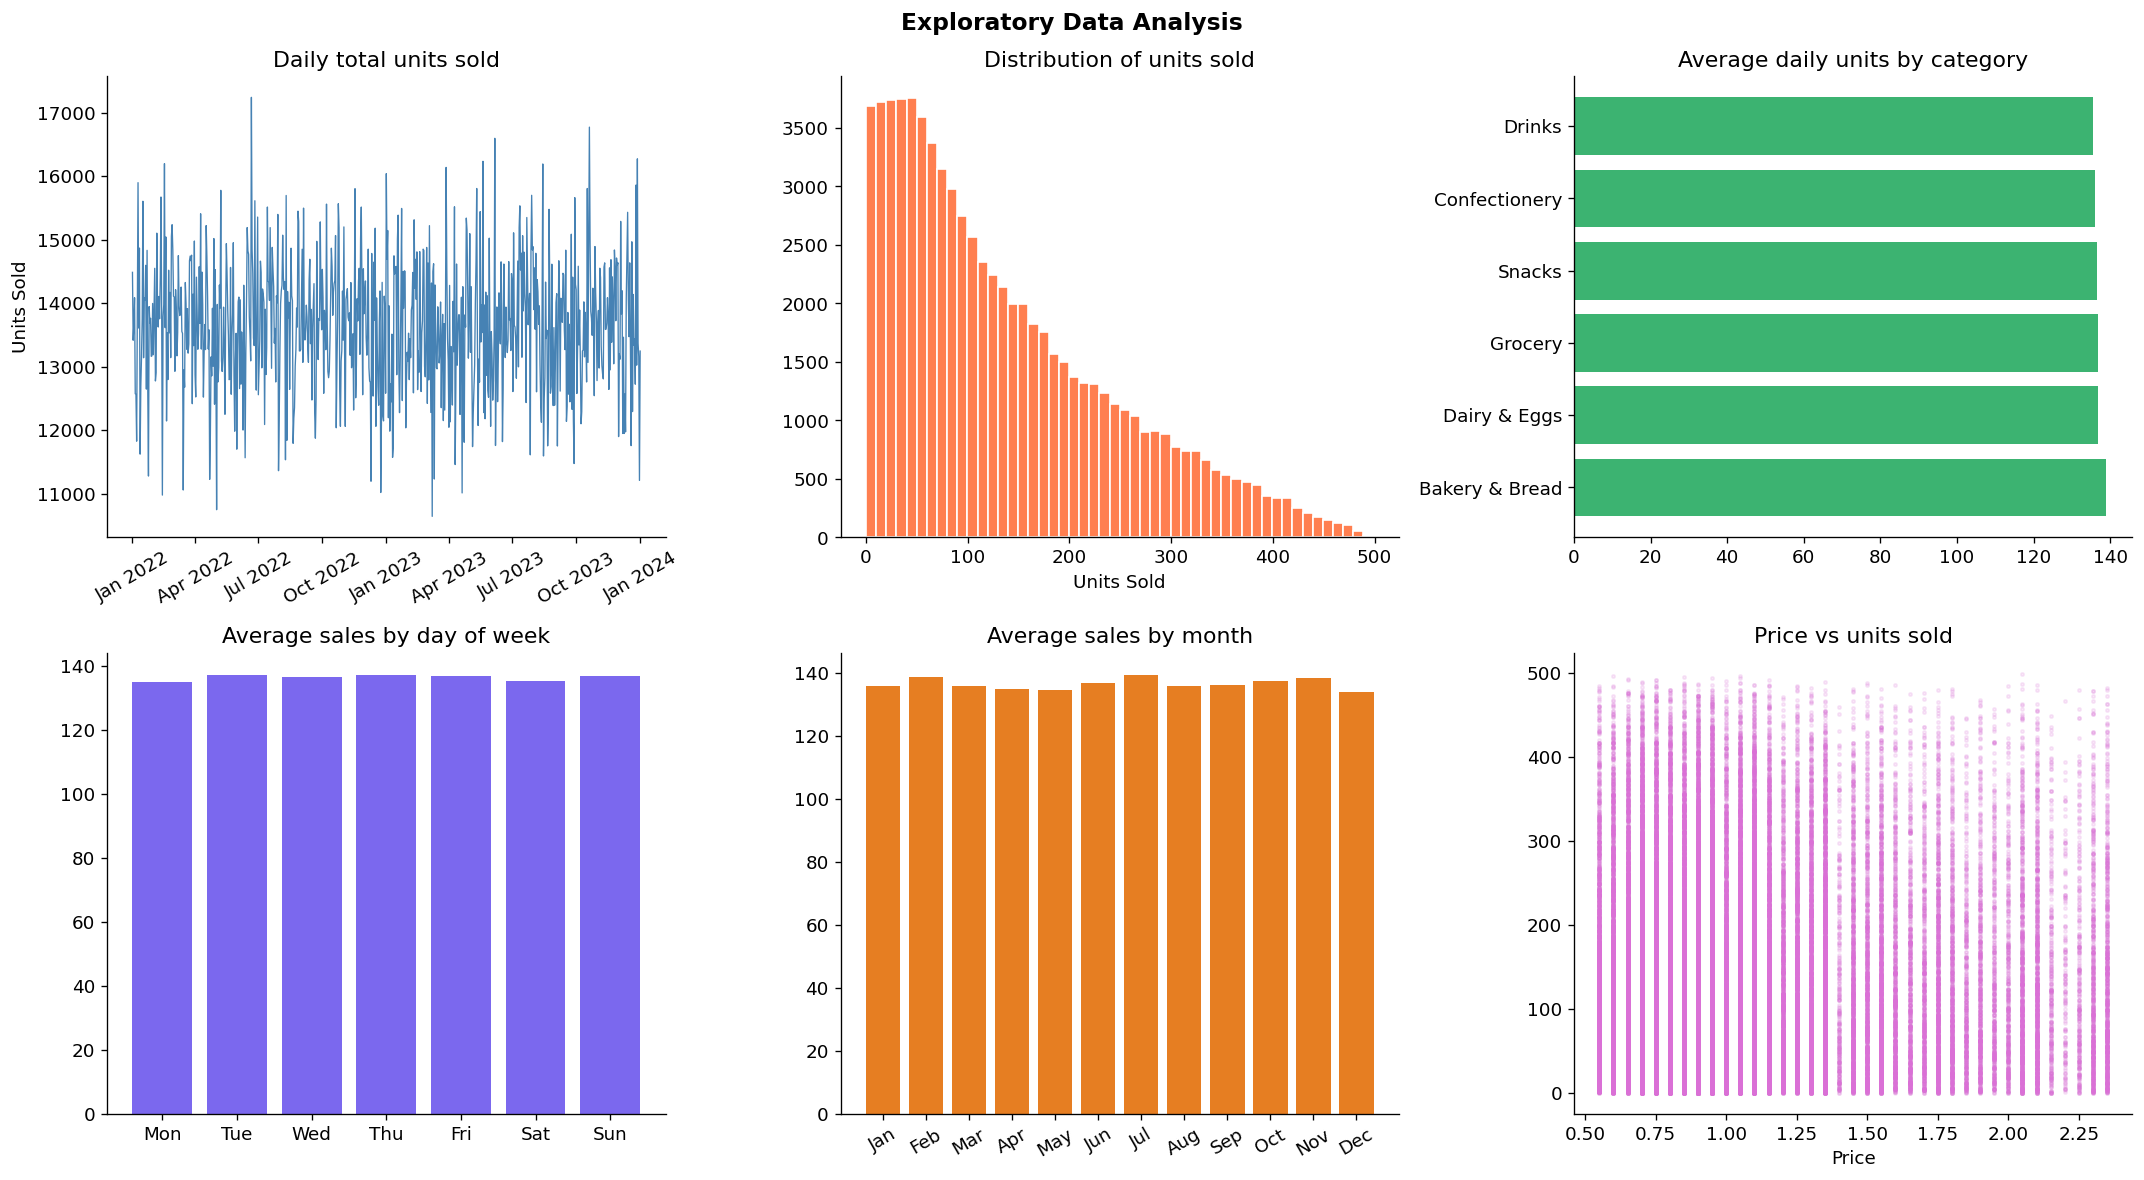

In [74]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')

daily = df_raw.groupby('Date')['Units Sold'].sum()
axes[0,0].plot(daily.index, daily.values, color='steelblue', lw=0.8)
axes[0,0].set_title('Daily total units sold')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].set_ylabel('Units Sold')

axes[0,1].hist(df_raw['Units Sold'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Distribution of units sold')
axes[0,1].set_xlabel('Units Sold')

cat_avg = df_raw.groupby('Category')['Units Sold'].mean().sort_values(ascending=False)
axes[0,2].barh(cat_avg.index, cat_avg.values, color='mediumseagreen')
axes[0,2].set_title('Average daily units by category')

dow_avg = df_raw.groupby(df_raw['Date'].dt.dayofweek)['Units Sold'].mean()
axes[1,0].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow_avg.values, color='#7b68ee')
axes[1,0].set_title('Average sales by day of week')

mon_avg = df_raw.groupby(df_raw['Date'].dt.month)['Units Sold'].mean()
mon_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1,1].bar([mon_labels[m-1] for m in mon_avg.index], mon_avg.values, color='#e67e22')
axes[1,1].set_title('Average sales by month')
axes[1,1].tick_params(axis='x', rotation=30)

axes[1,2].scatter(df_raw['Price'], df_raw['Units Sold'], alpha=0.15, s=4, color='orchid')
axes[1,2].set_title('Price vs units sold')
axes[1,2].set_xlabel('Price')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

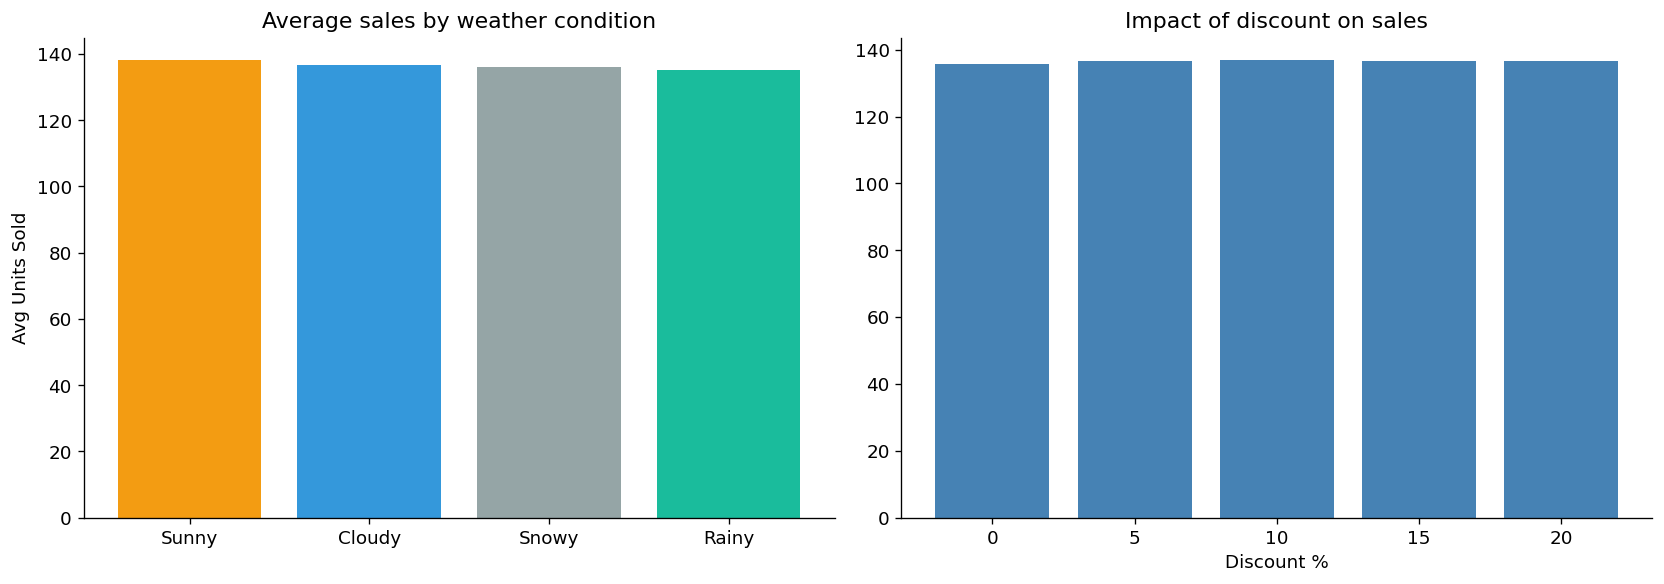

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weather_avg = df_raw.groupby('Weather Condition')['Units Sold'].mean().sort_values(ascending=False)
axes[0].bar(weather_avg.index, weather_avg.values, color=['#f39c12','#3498db','#95a5a6','#1abc9c'])
axes[0].set_title('Average sales by weather condition')
axes[0].set_ylabel('Avg Units Sold')

disc_avg = df_raw.groupby('Discount')['Units Sold'].mean()
axes[1].bar(disc_avg.index.astype(str), disc_avg.values, color='steelblue')
axes[1].set_title('Impact of discount on sales')
axes[1].set_xlabel('Discount %')

plt.tight_layout()
plt.savefig('eda_business_factors.png', bbox_inches='tight')
plt.show()

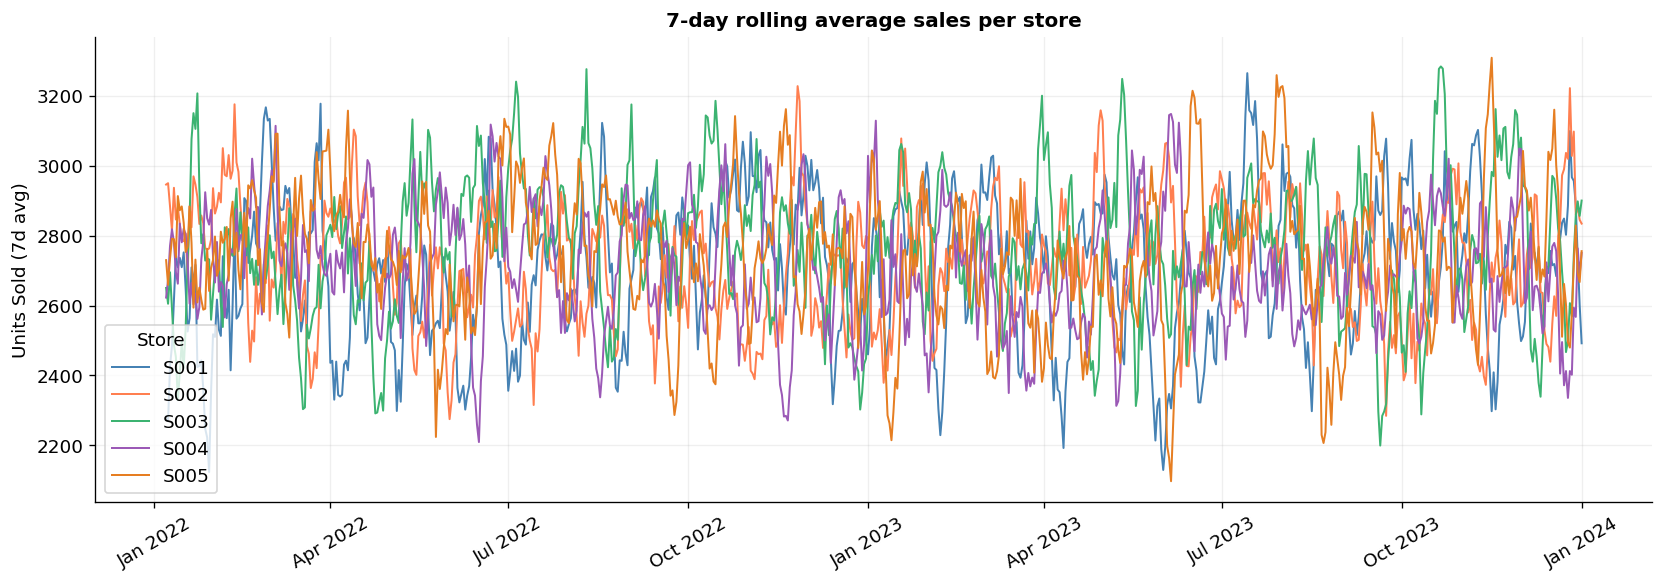

In [76]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue','coral','mediumseagreen','#9b59b6','#e67e22']
for i, store in enumerate(sorted(df_raw['Store ID'].unique())):
    s = df_raw[df_raw['Store ID']==store].groupby('Date')['Units Sold'].sum().rolling(7).mean()
    ax.plot(s.index, s.values, label=store, color=colors[i], lw=1.2)
ax.set_title('7-day rolling average sales per store', fontsize=12, fontweight='bold')
ax.set_ylabel('Units Sold (7d avg)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Store')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('store_trends.png', bbox_inches='tight')
plt.show()

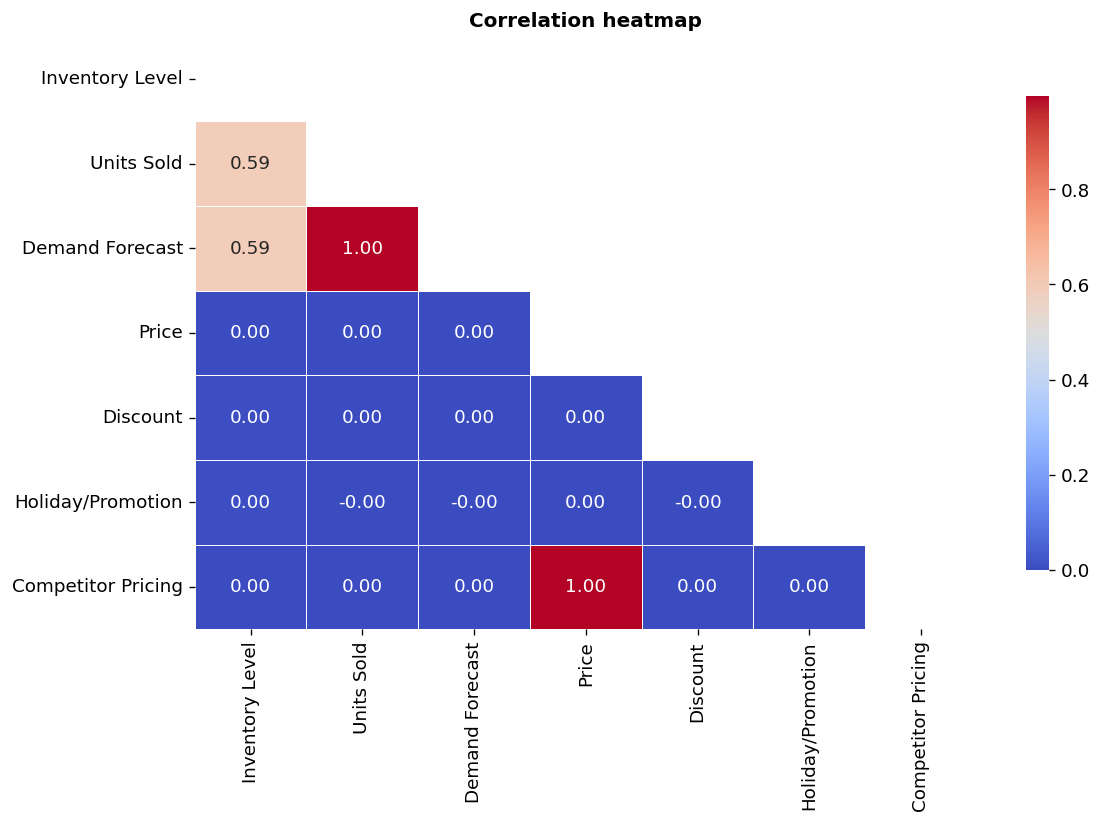

In [77]:
safe_num = df_raw.select_dtypes(include=[np.number]).drop(columns=['Units Ordered'], errors='ignore')
corr = safe_num.corr()
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 4. Preprocessing Pipeline

**Leakage rules:**
- `Demand Forecast` **retained** — upstream planning signal generated before sales; correlation 0.997 with `Units Sold` reflects a well-calibrated buyer forecast, not leakage.
- `Units Ordered` **removed** — correlation −0.001 with `Units Sold`; adds noise only.
- `Product Name` **removed** — free-text identifier with no predictive signal.
- All lag/rolling features use `.shift(1)` to prevent look-ahead on the current row.


In [78]:
df = df_raw.copy()

before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed : {before - len(df)}')

for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

EXCLUDE_COLS = ['Units Ordered', 'Product Name']
drop_cols    = [c for c in EXCLUDE_COLS if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f'Excluded columns   : {drop_cols}')

df.sort_values(['Store ID', 'Product ID', 'Date'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Clean shape        : {df.shape}')
print(f'Missing remaining  : {df.isnull().sum().sum()}')

Duplicates removed : 0
Excluded columns   : ['Units Ordered', 'Product Name']
Clean shape        : (73100, 14)
Missing remaining  : 0


In [79]:
def cap_outliers(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return series.clip(lower=q1 - factor*iqr, upper=q3 + factor*iqr)

print('Outlier capping (IQR x 3):')
for col in ['Units Sold', 'Price', 'Inventory Level', 'Competitor Pricing']:
    if col in df.columns:
        before_std = df[col].std()
        df[col] = cap_outliers(df[col])
        print(f'  {col:<30} std  {before_std:.2f}  ->  {df[col].std():.2f}')

Outlier capping (IQR x 3):
  Units Sold                     std  108.92  ->  108.92
  Price                          std  0.42  ->  0.42
  Inventory Level                std  129.95  ->  129.95
  Competitor Pricing             std  0.45  ->  0.45


In [80]:
le_store   = LabelEncoder()
le_product = LabelEncoder()
df['Store_enc']   = le_store.fit_transform(df['Store ID'].astype(str))
df['Product_enc'] = le_product.fit_transform(df['Product ID'].astype(str))

NOMINAL = [c for c in ['Weather Condition', 'Region', 'Category', 'Seasonality'] if c in df.columns]
ohe     = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_arr = ohe.fit_transform(df[NOMINAL].astype(str))
ohe_cols = ohe.get_feature_names_out(NOMINAL)
ohe_df   = pd.DataFrame(ohe_arr, columns=ohe_cols, index=df.index)
df = pd.concat([df.drop(columns=NOMINAL), ohe_df], axis=1)

print(f'OneHotEncoded : {NOMINAL}')
print(f'New OHE cols  : {list(ohe_cols)}')
print(f'Shape now     : {df.shape}')

OneHotEncoded : ['Weather Condition', 'Region', 'Category', 'Seasonality']
New OHE cols  : ['Weather Condition_Rainy', 'Weather Condition_Snowy', 'Weather Condition_Sunny', 'Region_North', 'Region_South', 'Region_West', 'Category_Confectionery', 'Category_Dairy & Eggs', 'Category_Drinks', 'Category_Grocery', 'Category_Snacks', 'Seasonality_Spring', 'Seasonality_Summer', 'Seasonality_Winter']
Shape now     : (73100, 26)


---
## 5. Feature Engineering

In [81]:
GRP = ['Store ID', 'Product ID']

# Lag features
for lag in [1, 2, 3, 7, 14]:
    df[f'Sales_Lag_{lag}'] = df.groupby(GRP)['Units Sold'].shift(lag)

# Rolling statistics (all shifted by 1 to avoid look-ahead)
for window in [3, 7, 14, 28]:
    df[f'RollingMean_{window}'] = (
        df.groupby(GRP)['Units Sold']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df[f'RollingStd_{window}'] = (
        df.groupby(GRP)['Units Sold']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0))
    )

df['RollingMax_7'] = df.groupby(GRP)['Units Sold'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).max())
df['RollingMin_7'] = df.groupby(GRP)['Units Sold'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).min())

# Business-logic features
df['Effective_Price']     = df['Price'] * (1 - df['Discount'] / 100)
df['Price_vs_Competitor'] = df['Price'] / (df['Competitor Pricing'] + 1e-5)
df['Inv_Sales_Ratio']     = (df['Inventory Level'] / (df['RollingMean_7'] + 1)).clip(upper=50)
df['Discount_x_Price']    = df['Discount'] * df['Price']

# Calendar features
df['DayOfWeek']  = df['Date'].dt.dayofweek
df['DayOfMonth'] = df['Date'].dt.day
df['Month']      = df['Date'].dt.month
df['Quarter']    = df['Date'].dt.quarter
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)
df['Year']       = df['Date'].dt.year

# Cyclic encodings
df['Month_sin'] = np.sin(2 * np.pi * df['Month']      / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month']      / 12)
df['DoW_sin']   = np.sin(2 * np.pi * df['DayOfWeek']  / 7)
df['DoW_cos']   = np.cos(2 * np.pi * df['DayOfWeek']  / 7)
df['WoY_sin']   = np.sin(2 * np.pi * df['WeekOfYear'] / 52)
df['WoY_cos']   = np.cos(2 * np.pi * df['WeekOfYear'] / 52)

# Upstream forecast refinement features
# Forecast_Lag_1 and Forecast_Error_Lag_1 are computed together to ensure consistency
df['Forecast_Lag_1']       = df.groupby(GRP)['Demand Forecast'].shift(1).fillna(0)
# Corrected: Calculate Forecast_Error_Lag_1 without apply to avoid index mismatch
lagged_units_sold = df.groupby(GRP)['Units Sold'].shift(1)
lagged_demand_forecast = df.groupby(GRP)['Demand Forecast'].shift(1)
df['Forecast_Error_Lag_1'] = (lagged_units_sold - lagged_demand_forecast).fillna(0)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Features created. Shape : {df.shape}')

Features created. Shape : (71700, 60)


In [82]:
TARGET = 'Units Sold'

EXCLUDE = ['Date', 'Store ID', 'Product ID', 'Store_enc', 'Product_enc', 'Units Sold']
CANDIDATE_FEATURES = [c for c in df.columns if c not in EXCLUDE]

print(f'Candidate features : {len(CANDIDATE_FEATURES)}')
for f in CANDIDATE_FEATURES:
    print(f'  {f}')

Candidate features : 54
  Inventory Level
  Demand Forecast
  Price
  Discount
  Holiday/Promotion
  Competitor Pricing
  Weather Condition_Rainy
  Weather Condition_Snowy
  Weather Condition_Sunny
  Region_North
  Region_South
  Region_West
  Category_Confectionery
  Category_Dairy & Eggs
  Category_Drinks
  Category_Grocery
  Category_Snacks
  Seasonality_Spring
  Seasonality_Summer
  Seasonality_Winter
  Sales_Lag_1
  Sales_Lag_2
  Sales_Lag_3
  Sales_Lag_7
  Sales_Lag_14
  RollingMean_3
  RollingStd_3
  RollingMean_7
  RollingStd_7
  RollingMean_14
  RollingStd_14
  RollingMean_28
  RollingStd_28
  RollingMax_7
  RollingMin_7
  Effective_Price
  Price_vs_Competitor
  Inv_Sales_Ratio
  Discount_x_Price
  DayOfWeek
  DayOfMonth
  Month
  Quarter
  WeekOfYear
  IsWeekend
  Year
  Month_sin
  Month_cos
  DoW_sin
  DoW_cos
  WoY_sin
  WoY_cos
  Forecast_Lag_1
  Forecast_Error_Lag_1


---
## 6. Feature Selection

Three methods combined by majority vote (≥ 2/3):
1. **Mutual information** — non-linear dependencies
2. **F-regression** — linear significance (p < 0.05)
3. **Lasso regularisation** — sparsity-based elimination

Feature selection is performed **only on the training time window** (first 70% of dates) to prevent test-set leakage.


In [83]:
# Use only training-period dates for feature selection to prevent leakage
all_dates   = df['Date'].sort_values().unique()
cutoff_date = all_dates[int(len(all_dates) * 0.70)]
df_sel      = df[df['Date'] < cutoff_date].copy()

SELECTION_N = min(20000, len(df_sel))
df_sel      = df_sel.sample(n=SELECTION_N, random_state=SEED)

X_sel = df_sel[CANDIDATE_FEATURES].values
y_sel = df_sel[TARGET].values

mi_scores    = mutual_info_regression(X_sel, y_sel, random_state=SEED)
mi_df        = pd.DataFrame({'Feature': CANDIDATE_FEATURES, 'MI_Score': mi_scores})
mi_threshold = mi_df['MI_Score'].quantile(0.40)
mi_selected  = set(mi_df[mi_df['MI_Score'] >= mi_threshold]['Feature'])
print(f'Mutual information selected : {len(mi_selected)} features')

f_scores, f_pvals = f_regression(X_sel, y_sel)
f_df       = pd.DataFrame({'Feature': CANDIDATE_FEATURES, 'P_Value': f_pvals})
f_selected = set(f_df[f_df['P_Value'] < 0.05]['Feature'])
print(f'F-regression selected       : {len(f_selected)} features')

scaler_sel    = MinMaxScaler()
X_sel_sc      = scaler_sel.fit_transform(X_sel)
lasso         = Lasso(alpha=0.01, max_iter=5000, random_state=SEED)
lasso.fit(X_sel_sc, y_sel)
lasso_selected = set(CANDIDATE_FEATURES[i] for i, c in enumerate(lasso.coef_) if abs(c) > 0)
print(f'Lasso selected              : {len(lasso_selected)} features')

vote_map = {f: int(f in mi_selected) + int(f in f_selected) + int(f in lasso_selected)
            for f in CANDIDATE_FEATURES}
SELECTED_FEATURES = [f for f, v in vote_map.items() if v >= 2]
print(f'\nFinal selected (>=2/3 votes): {len(SELECTED_FEATURES)} features')
print(SELECTED_FEATURES)

Mutual information selected : 54 features
F-regression selected       : 6 features
Lasso selected              : 21 features

Final selected (>=2/3 votes): 22 features
['Inventory Level', 'Demand Forecast', 'Price', 'Discount', 'Holiday/Promotion', 'Weather Condition_Rainy', 'Weather Condition_Sunny', 'Region_North', 'Region_South', 'Region_West', 'Category_Confectionery', 'Category_Dairy & Eggs', 'Seasonality_Spring', 'Seasonality_Summer', 'Sales_Lag_2', 'Inv_Sales_Ratio', 'DayOfWeek', 'DayOfMonth', 'Quarter', 'Year', 'Month_cos', 'DoW_sin']


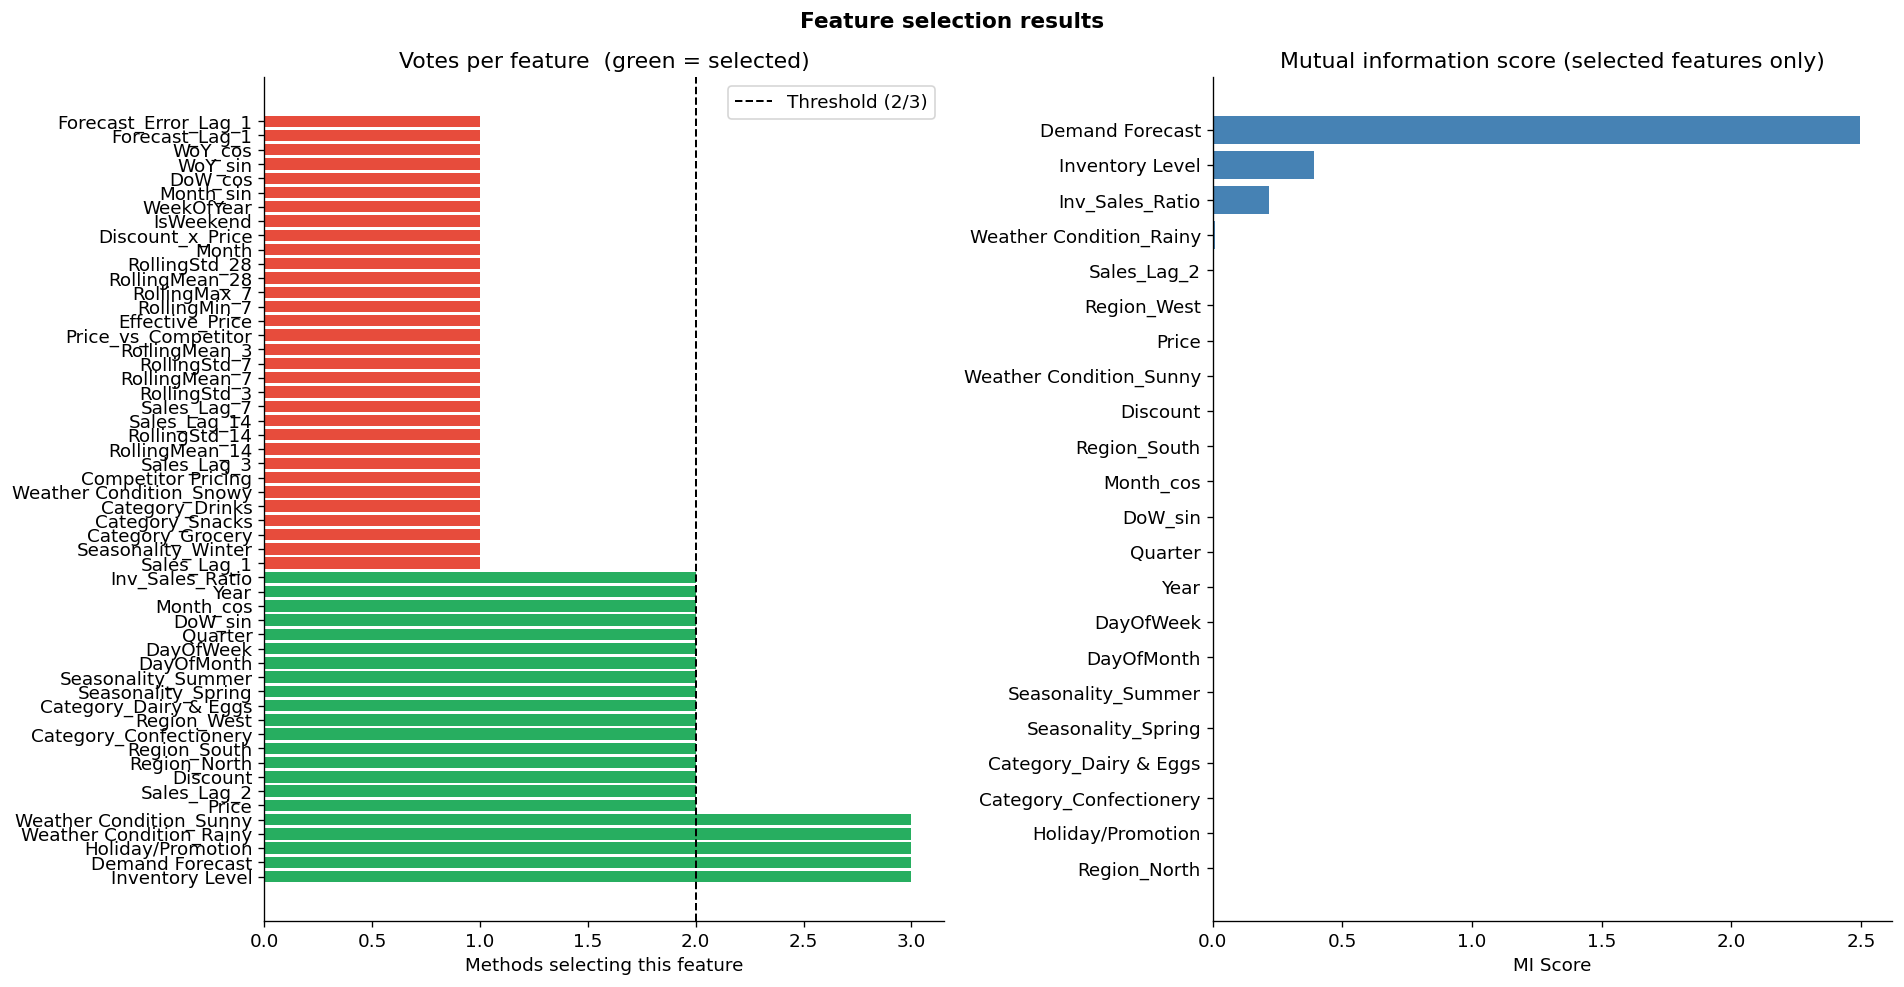

Features removed by selection: ['Competitor Pricing', 'Weather Condition_Snowy', 'Category_Drinks', 'Category_Grocery', 'Category_Snacks', 'Seasonality_Winter', 'Sales_Lag_1', 'Sales_Lag_3', 'Sales_Lag_7', 'Sales_Lag_14', 'RollingMean_3', 'RollingStd_3', 'RollingMean_7', 'RollingStd_7', 'RollingMean_14', 'RollingStd_14', 'RollingMean_28', 'RollingStd_28', 'RollingMax_7', 'RollingMin_7', 'Effective_Price', 'Price_vs_Competitor', 'Discount_x_Price', 'Month', 'WeekOfYear', 'IsWeekend', 'Month_sin', 'DoW_cos', 'WoY_sin', 'WoY_cos', 'Forecast_Lag_1', 'Forecast_Error_Lag_1']


In [84]:
vote_df = (pd.DataFrame([{'Feature': f, 'Votes': v} for f, v in vote_map.items()])
           .sort_values('Votes', ascending=False))
mi_plot = mi_df.set_index('Feature').loc[SELECTED_FEATURES].sort_values('MI_Score', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(SELECTED_FEATURES)*0.38)))
fig.suptitle('Feature selection results', fontsize=13, fontweight='bold')

colors_vote = ['#e74c3c' if v < 2 else '#27ae60' for v in vote_df['Votes']]
axes[0].barh(vote_df['Feature'], vote_df['Votes'], color=colors_vote)
axes[0].axvline(2, color='black', linestyle='--', lw=1.2, label='Threshold (2/3)')
axes[0].set_title('Votes per feature  (green = selected)')
axes[0].set_xlabel('Methods selecting this feature')
axes[0].legend()

axes[1].barh(mi_plot.index, mi_plot['MI_Score'], color='steelblue')
axes[1].set_title('Mutual information score (selected features only)')
axes[1].set_xlabel('MI Score')

plt.tight_layout()
plt.savefig('feature_selection.png', bbox_inches='tight')
plt.show()

removed = [f for f in CANDIDATE_FEATURES if f not in SELECTED_FEATURES]
print(f'Features removed by selection: {removed}')

---
## 7. Train / Validation / Test Split

Per-entity chronological split (70 / 15 / 15). Each Store+Product pair is split independently in time so sequences never cross entity boundaries and there is no temporal leakage between partitions.


In [85]:
SEQ_LEN  = 21
MIN_ROWS = SEQ_LEN + 10

train_parts, val_parts, test_parts = [], [], []
for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
    grp = grp.sort_values('Date').reset_index(drop=True)
    n = len(grp)
    if n < MIN_ROWS:
        continue
    t1 = int(n * 0.70)
    t2 = int(n * 0.85)
    train_parts.append(grp.iloc[:t1])
    val_parts.append(grp.iloc[t1:t2])
    test_parts.append(grp.iloc[t2:])

train_df = pd.concat(train_parts).reset_index(drop=True)
val_df   = pd.concat(val_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts).reset_index(drop=True)

print(f'Training   : {len(train_df):>8,} rows')
print(f'Validation : {len(val_df):>8,} rows')
print(f'Test       : {len(test_df):>8,} rows')
print(f'Features   : {len(SELECTED_FEATURES)}')

Training   :   50,100 rows
Validation :   10,800 rows
Test       :   10,800 rows
Features   : 22


In [86]:
X_train_raw = train_df[SELECTED_FEATURES].values;  y_train = train_df[TARGET].values
X_val_raw   = val_df[SELECTED_FEATURES].values;    y_val   = val_df[TARGET].values
X_test_raw  = test_df[SELECTED_FEATURES].values;   y_test  = test_df[TARGET].values

# Scaler fitted on training data only; applied to val/test
lstm_feat_scaler = MinMaxScaler()
X_train_sc = lstm_feat_scaler.fit_transform(X_train_raw)
X_val_sc   = lstm_feat_scaler.transform(X_val_raw)
X_test_sc  = lstm_feat_scaler.transform(X_test_raw)

target_scaler = MinMaxScaler()
y_train_sc = target_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_val_sc   = target_scaler.transform(y_val.reshape(-1,1)).ravel()
y_test_sc  = target_scaler.transform(y_test.reshape(-1,1)).ravel()

print('MinMaxScaler fitted on training partition only.')
print(f'Feature matrix shape : {X_train_raw.shape}')

MinMaxScaler fitted on training partition only.
Feature matrix shape : (50100, 22)


In [87]:
def build_sequences(df_split, X_scaled, y_scaled, seq_len):
    """Build (samples, timesteps, features) sequences per entity.
    Uses positional indexing derived from the split's own reset index
    to avoid any dependency on global DataFrame labels.
    """
    Xs, ys = [], []
    for _, grp in df_split.groupby(['Store ID', 'Product ID']):
        # grp.index holds the reset integer positions into df_split
        pos = grp.index.tolist()
        if len(pos) <= seq_len:
            continue
        Xg = X_scaled[pos]
        yg = y_scaled[pos]
        for i in range(seq_len, len(pos)):
            Xs.append(Xg[i - seq_len : i])
            ys.append(yg[i])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = build_sequences(train_df, X_train_sc, y_train_sc, SEQ_LEN)
X_val_seq,   y_val_seq   = build_sequences(val_df,   X_val_sc,   y_val_sc,   SEQ_LEN)
X_test_seq,  y_test_seq  = build_sequences(test_df,  X_test_sc,  y_test_sc,  SEQ_LEN)
y_test_actual = target_scaler.inverse_transform(y_test_seq.reshape(-1,1)).ravel()

print(f'LSTM train : {X_train_seq.shape}  (samples, timesteps, features)')
print(f'LSTM val   : {X_val_seq.shape}')
print(f'LSTM test  : {X_test_seq.shape}')

LSTM train : (48000, 21, 22)  (samples, timesteps, features)
LSTM val   : (8700, 21, 22)
LSTM test  : (8700, 21, 22)


In [88]:
def align_xgb_rows(df_split, X_raw, y_arr, seq_len):
    """Return the subset of XGBoost rows that correspond exactly
    to the LSTM prediction targets (i.e. rows from position seq_len onward
    within each entity group).
    """
    X_out, y_out = [], []
    for _, grp in df_split.groupby(['Store ID', 'Product ID']):
        pos = grp.index.tolist()
        if len(pos) <= seq_len:
            continue
        X_out.append(X_raw[pos[seq_len:]])
        y_out.append(y_arr[pos[seq_len:]])
    return np.vstack(X_out), np.concatenate(y_out)

X_tr_xgb, y_tr_xgb = align_xgb_rows(train_df, X_train_raw, y_train, SEQ_LEN)
X_vl_xgb, y_vl_xgb = align_xgb_rows(val_df,   X_val_raw,   y_val,   SEQ_LEN)
X_te_xgb, y_te_xgb = align_xgb_rows(test_df,  X_test_raw,  y_test,  SEQ_LEN)

assert len(X_tr_xgb) == len(X_train_seq), 'Train alignment mismatch'
assert len(X_vl_xgb) == len(X_val_seq),   'Val alignment mismatch'
assert len(X_te_xgb) == len(X_test_seq),  'Test alignment mismatch'
print('Row alignment confirmed.')
print(f'XGBoost train : {X_tr_xgb.shape}  (raw, unscaled)')

Row alignment confirmed.
XGBoost train : (48000, 22)  (raw, unscaled)


---
## 8. Baseline Models

In [89]:
# Naive and seasonal baselines are typically based on specific lag features.
# However, 'Sales_Lag_1' and 'Sales_Lag_7' were removed during feature selection.
# Therefore, we will only compute the Linear Regression baseline as it uses the SELECTED_FEATURES.

lr_model = LinearRegression()
lr_model.fit(X_tr_xgb, y_tr_xgb)
lr_preds = lr_model.predict(X_te_xgb)

print(f'Linear Regression MAE  : {mean_absolute_error(y_test_actual, lr_preds):.2f}')

Linear Regression MAE  : 7.50


---
## 9. XGBoost Model

XGBoost receives raw unscaled features. Tree-based models split on threshold comparisons, so monotonic scaling has no effect on predictions.


In [90]:
xgb_model = XGBRegressor(
    n_estimators          = 800,
    learning_rate         = 0.03,
    max_depth             = 6,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    colsample_bylevel     = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 2.0,
    gamma                 = 0.1,
    early_stopping_rounds = 30,
    eval_metric           = 'mae',
    random_state          = SEED,
    verbosity             = 0,
)

xgb_model.fit(X_tr_xgb, y_tr_xgb,
              eval_set=[(X_vl_xgb, y_vl_xgb)],
              verbose=100)
xgb_preds = xgb_model.predict(X_te_xgb)

print(f'\nBest iteration : {xgb_model.best_iteration}')
print(f'XGBoost MAE    : {mean_absolute_error(y_test_actual, xgb_preds):.2f}')
print(f'XGBoost R2     : {r2_score(y_test_actual, xgb_preds):.3f}')

[0]	validation_0-mae:86.93423
[100]	validation_0-mae:9.99405
[200]	validation_0-mae:7.38756
[300]	validation_0-mae:7.33150
[375]	validation_0-mae:7.33172

Best iteration : 345
XGBoost MAE    : 7.27
XGBoost R2     : 0.994


In [91]:
print('Walk-forward cross-validation (5 folds)...')
tscv = TimeSeriesSplit(n_splits=5)
cv_maes, cv_r2s = [], []
for fold, (tri, vli) in enumerate(tscv.split(X_tr_xgb)):
    m = XGBRegressor(n_estimators=500, learning_rate=0.04, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8,
                     random_state=SEED, verbosity=0)
    m.fit(X_tr_xgb[tri], y_tr_xgb[tri])
    fp = m.predict(X_tr_xgb[vli])
    cv_maes.append(mean_absolute_error(y_tr_xgb[vli], fp))
    cv_r2s.append(r2_score(y_tr_xgb[vli], fp))
    print(f'  Fold {fold+1}  MAE={cv_maes[-1]:.2f}  R2={cv_r2s[-1]:.3f}')
print(f'\nCV MAE : {np.mean(cv_maes):.2f} +/- {np.std(cv_maes):.2f}')
print(f'CV R2  : {np.mean(cv_r2s):.3f} +/- {np.std(cv_r2s):.3f}')

Walk-forward cross-validation (5 folds)...
  Fold 1  MAE=7.70  R2=0.993
  Fold 2  MAE=7.47  R2=0.993
  Fold 3  MAE=7.30  R2=0.994
  Fold 4  MAE=7.32  R2=0.994
  Fold 5  MAE=7.25  R2=0.994

CV MAE : 7.41 +/- 0.16
CV R2  : 0.994 +/- 0.000


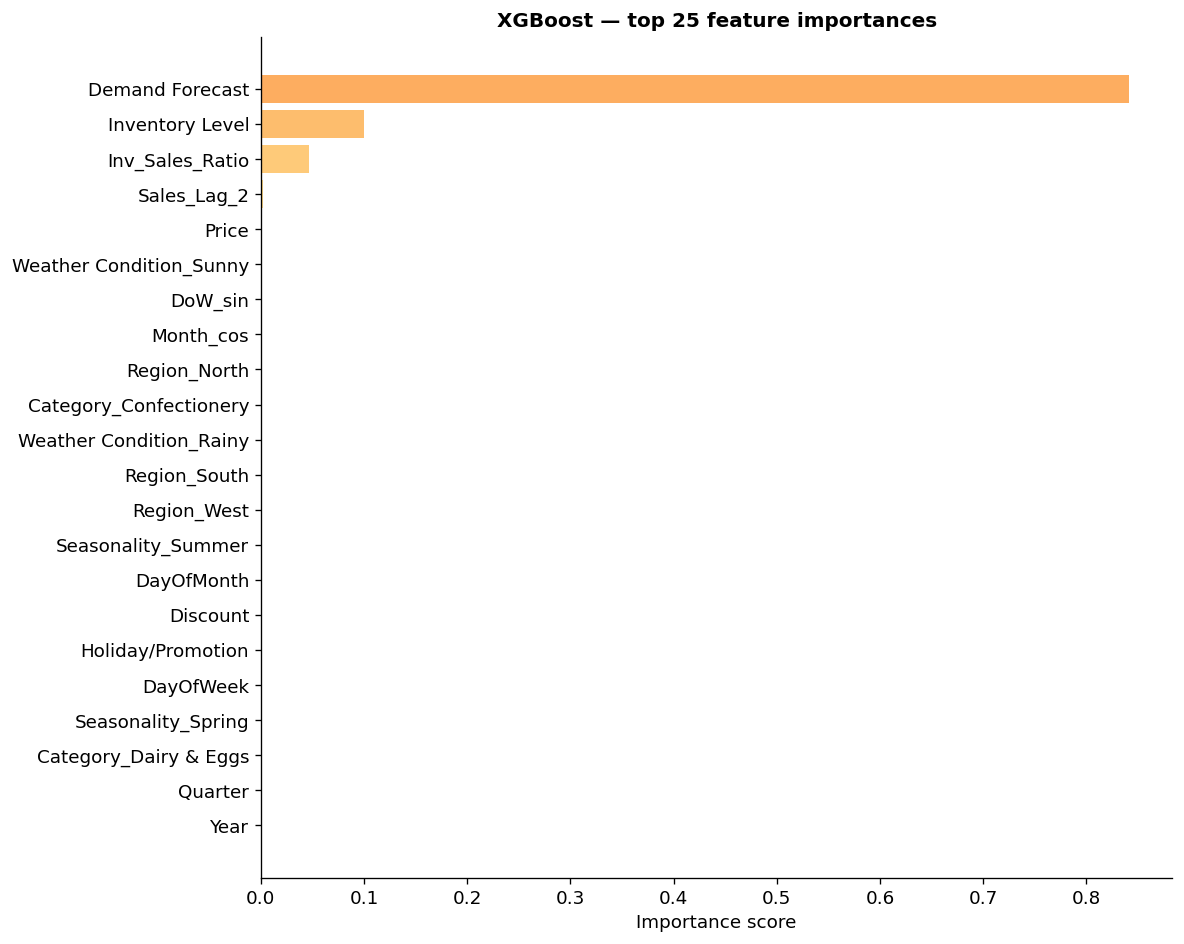

In [92]:
imp_df = (pd.DataFrame({'Feature': SELECTED_FEATURES,
                        'Importance': xgb_model.feature_importances_})
           .sort_values('Importance', ascending=False).head(25))

plt.figure(figsize=(10, 8))
palette = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(imp_df)))
plt.barh(imp_df['Feature'][::-1], imp_df['Importance'][::-1], color=palette[::-1])
plt.xlabel('Importance score')
plt.title('XGBoost — top 25 feature importances', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 10. LSTM Model

Stacked LSTM with BatchNorm and Dropout over a 21-day look-back window. Trained with Huber loss (robust to outliers) and early stopping on validation loss.


In [93]:
def build_lstm(seq_len, n_features):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(seq_len, n_features)),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ], name='lstm_demand_forecaster')
    model.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])
    return model

lstm_model = build_lstm(SEQ_LEN, X_train_seq.shape[2])
lstm_model.summary()

Model: "lstm_demand_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 21, 128)        │        77,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,761 (522.50 KB)

 Trainable params: 133,377 (521.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [94]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_lstm.keras', monitor='val_loss', save_best_only=True, verbose=0),
]

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=150, batch_size=256,
    callbacks=callbacks, verbose=1
)

Epoch 1/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0381 - mae: 0.2158 - val_loss: 0.0340 - val_mae: 0.1879 - learning_rate: 0.0010
Epoch 2/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0259 - mae: 0.1842 - val_loss: 0.0245 - val_mae: 0.1791 - learning_rate: 0.0010
Epoch 3/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0252 - mae: 0.1823 - val_loss: 0.0248 - val_mae: 0.1781 - learning_rate: 0.0010
Epoch 4/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0249 - mae: 0.1817 - val_loss: 0.0250 - val_mae: 0.1772 - learning_rate: 0.0010
Epoch 5/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0247 - mae: 0.1810 - val_loss: 0.0248 - val_mae: 0.1775 - learning_rate: 0.0010
Epoch 6/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0246 - mae: 0.1808 - val_loss: 0.0243 - val_mae: 0.1802 - learning_rate: 0.0010
Epoch 7/150
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0246 - mae: 0.1807 - val_loss: 0.0243 - val_mae: 0.1815 - learning_rate:

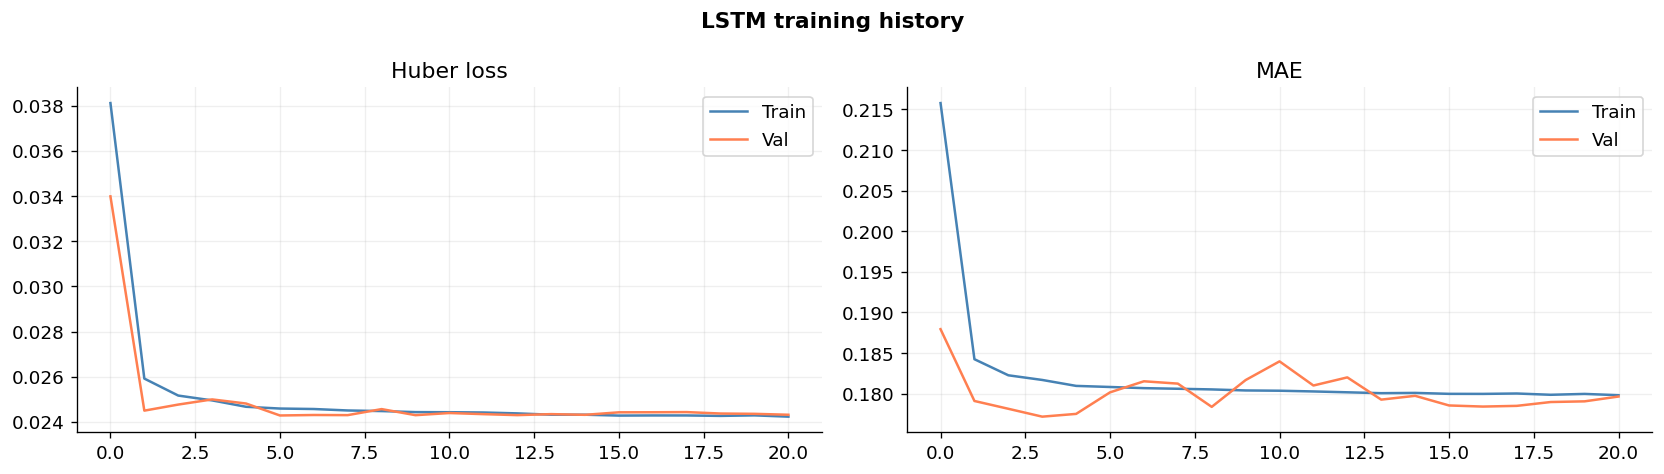

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('LSTM training history', fontsize=13, fontweight='bold')
for ax, key, label in zip(axes, ['loss','mae'], ['Huber loss','MAE']):
    ax.plot(history.history[key],          label='Train', color='steelblue', lw=1.5)
    ax.plot(history.history[f'val_{key}'], label='Val',   color='coral',     lw=1.5)
    ax.set_title(label); ax.legend(); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('lstm_training_history.png', bbox_inches='tight')
plt.show()

In [96]:
lstm_pred_sc = lstm_model.predict(X_test_seq, verbose=0).ravel()
lstm_preds   = np.clip(
    target_scaler.inverse_transform(lstm_pred_sc.reshape(-1,1)).ravel(), 0, None)
print(f'LSTM MAE : {mean_absolute_error(y_test_actual, lstm_preds):.2f}')
print(f'LSTM R2  : {r2_score(y_test_actual, lstm_preds):.3f}')

LSTM MAE : 88.34
LSTM R2  : -0.000


---
## 11. Hybrid Ensemble — Ridge Stacking Meta-Learner

Ridge regression is trained on **validation-set predictions** from both models using the same aligned row set, guaranteeing the meta-learner learns from consistent (LSTM prediction, XGBoost prediction, true target) triples.


In [97]:
# Validation predictions — both arrays correspond to the same aligned rows
lstm_val_sc = lstm_model.predict(X_val_seq, verbose=0).ravel()
lstm_val_p  = np.clip(target_scaler.inverse_transform(lstm_val_sc.reshape(-1,1)).ravel(), 0, None)
xgb_val_p   = xgb_model.predict(X_vl_xgb)

assert len(lstm_val_p) == len(xgb_val_p) == len(y_vl_xgb), \
    f'Alignment error: {len(lstm_val_p)} vs {len(xgb_val_p)} vs {len(y_vl_xgb)}'

meta_learner = Ridge(alpha=1.0)
meta_learner.fit(np.column_stack([lstm_val_p, xgb_val_p]), y_vl_xgb)

print('Ridge stacking meta-learner fitted.')
print(f'  LSTM coefficient    : {meta_learner.coef_[0]:.4f}')
print(f'  XGBoost coefficient : {meta_learner.coef_[1]:.4f}')
print(f'  Intercept           : {meta_learner.intercept_:.4f}')

Ridge stacking meta-learner fitted.
  LSTM coefficient    : 0.0679
  XGBoost coefficient : 1.0017
  Intercept           : -9.6393


In [98]:
ensemble_preds = np.clip(
    meta_learner.predict(np.column_stack([lstm_preds, xgb_preds])), 0, None)
print(f'Ensemble MAE : {mean_absolute_error(y_test_actual, ensemble_preds):.2f}')
print(f'Ensemble R2  : {r2_score(y_test_actual, ensemble_preds):.3f}')

Ensemble MAE : 7.27
Ensemble R2  : 0.994


---
## 12. Evaluation & Comparison

In [99]:
def smape(yt, yp):
    d = (np.abs(yt) + np.abs(yp)) / 2
    m = d > 0
    return np.mean(np.abs(yt[m] - yp[m]) / d[m]) * 100

def mape(yt, yp):
    m = yt > 0
    return np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100

def forecast_accuracy(yt, yp):
    return max(0, (1 - np.sum(np.abs(yt - yp)) / (np.sum(np.abs(yt)) + 1e-8)) * 100)

def evaluate(yt, yp, name):
    mse_val = mean_squared_error(yt, yp)
    return {
        'Model'      : name,
        'MAE'        : mean_absolute_error(yt, yp),
        'RMSE'       : np.sqrt(mse_val),
        'R2'         : r2_score(yt, yp),
        'MAPE_%'     : mape(yt, yp),
        'SMAPE_%'    : smape(yt, yp),
        'Accuracy_%' : forecast_accuracy(yt, yp),
    }

y_true  = y_test_actual
results = [
    evaluate(y_true, lr_preds,       'Linear Regression'),
    evaluate(y_true, xgb_preds,      'XGBoost'),
    evaluate(y_true, lstm_preds,     'LSTM'),
    evaluate(y_true, ensemble_preds, 'Hybrid Ensemble'),
]

res_df = pd.DataFrame(results).set_index('Model').round(3)

print()
print('=' * 75)
print('           MODEL EVALUATION  -  TEST SET')
print('=' * 75)
print(res_df.to_string())
print('=' * 75)
print(f'Best MAE      : {res_df["MAE"].idxmin()}')
print(f'Best R2       : {res_df["R2"].idxmax()}')
print(f'Best Accuracy : {res_df["Accuracy_%"].idxmax()}  ({res_df["Accuracy_%"].max():.1f}%)')


           MODEL EVALUATION  -  TEST SET
                      MAE     RMSE     R2   MAPE_%  SMAPE_%  Accuracy_%
Model                                                                  
Linear Regression   7.503    8.685  0.994   23.145   17.198      94.523
XGBoost             7.269    8.531  0.994   19.876   13.989      94.694
LSTM               88.344  107.906 -0.000  335.753   71.375      35.510
Hybrid Ensemble     7.266    8.529  0.994   19.404   13.993      94.696
Best MAE      : Hybrid Ensemble
Best R2       : Linear Regression
Best Accuracy : Hybrid Ensemble  (94.7%)


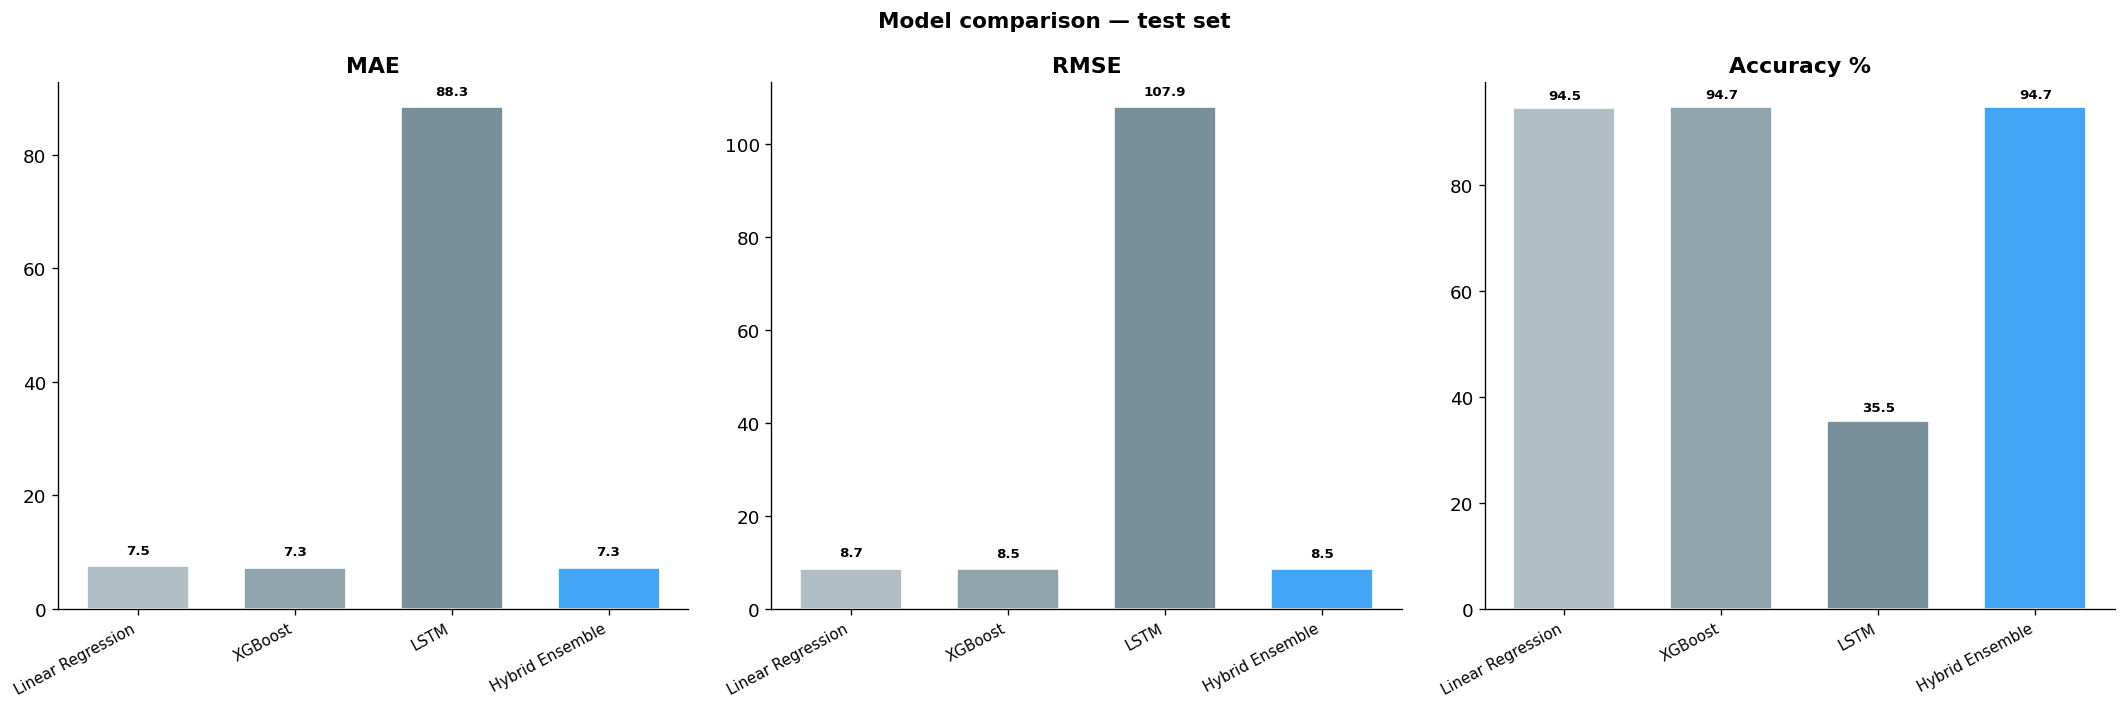

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model comparison — test set', fontsize=13, fontweight='bold')

palette = ['#b0bec5','#90a4ae','#78909c','#42a5f5','#ef5350','#66bb6a']
models  = res_df.index.tolist()
xs      = range(len(models))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'Accuracy_%']):
    vals = res_df[metric].values
    bars = ax.bar(xs, vals, color=palette, edgecolor='white', width=0.65)
    ax.set_xticks(list(xs))
    ax.set_xticklabels(models, rotation=28, ha='right', fontsize=9)
    ax.set_title(metric.replace('_',' '), fontweight='bold')
    for bar, v in zip(bars, vals):
        off = 0.02 * (max(vals) - min(vals) + 1e-5)
        ax.text(bar.get_x() + bar.get_width()/2,
                v + off if v >= 0 else v - off,
                f'{v:.1f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

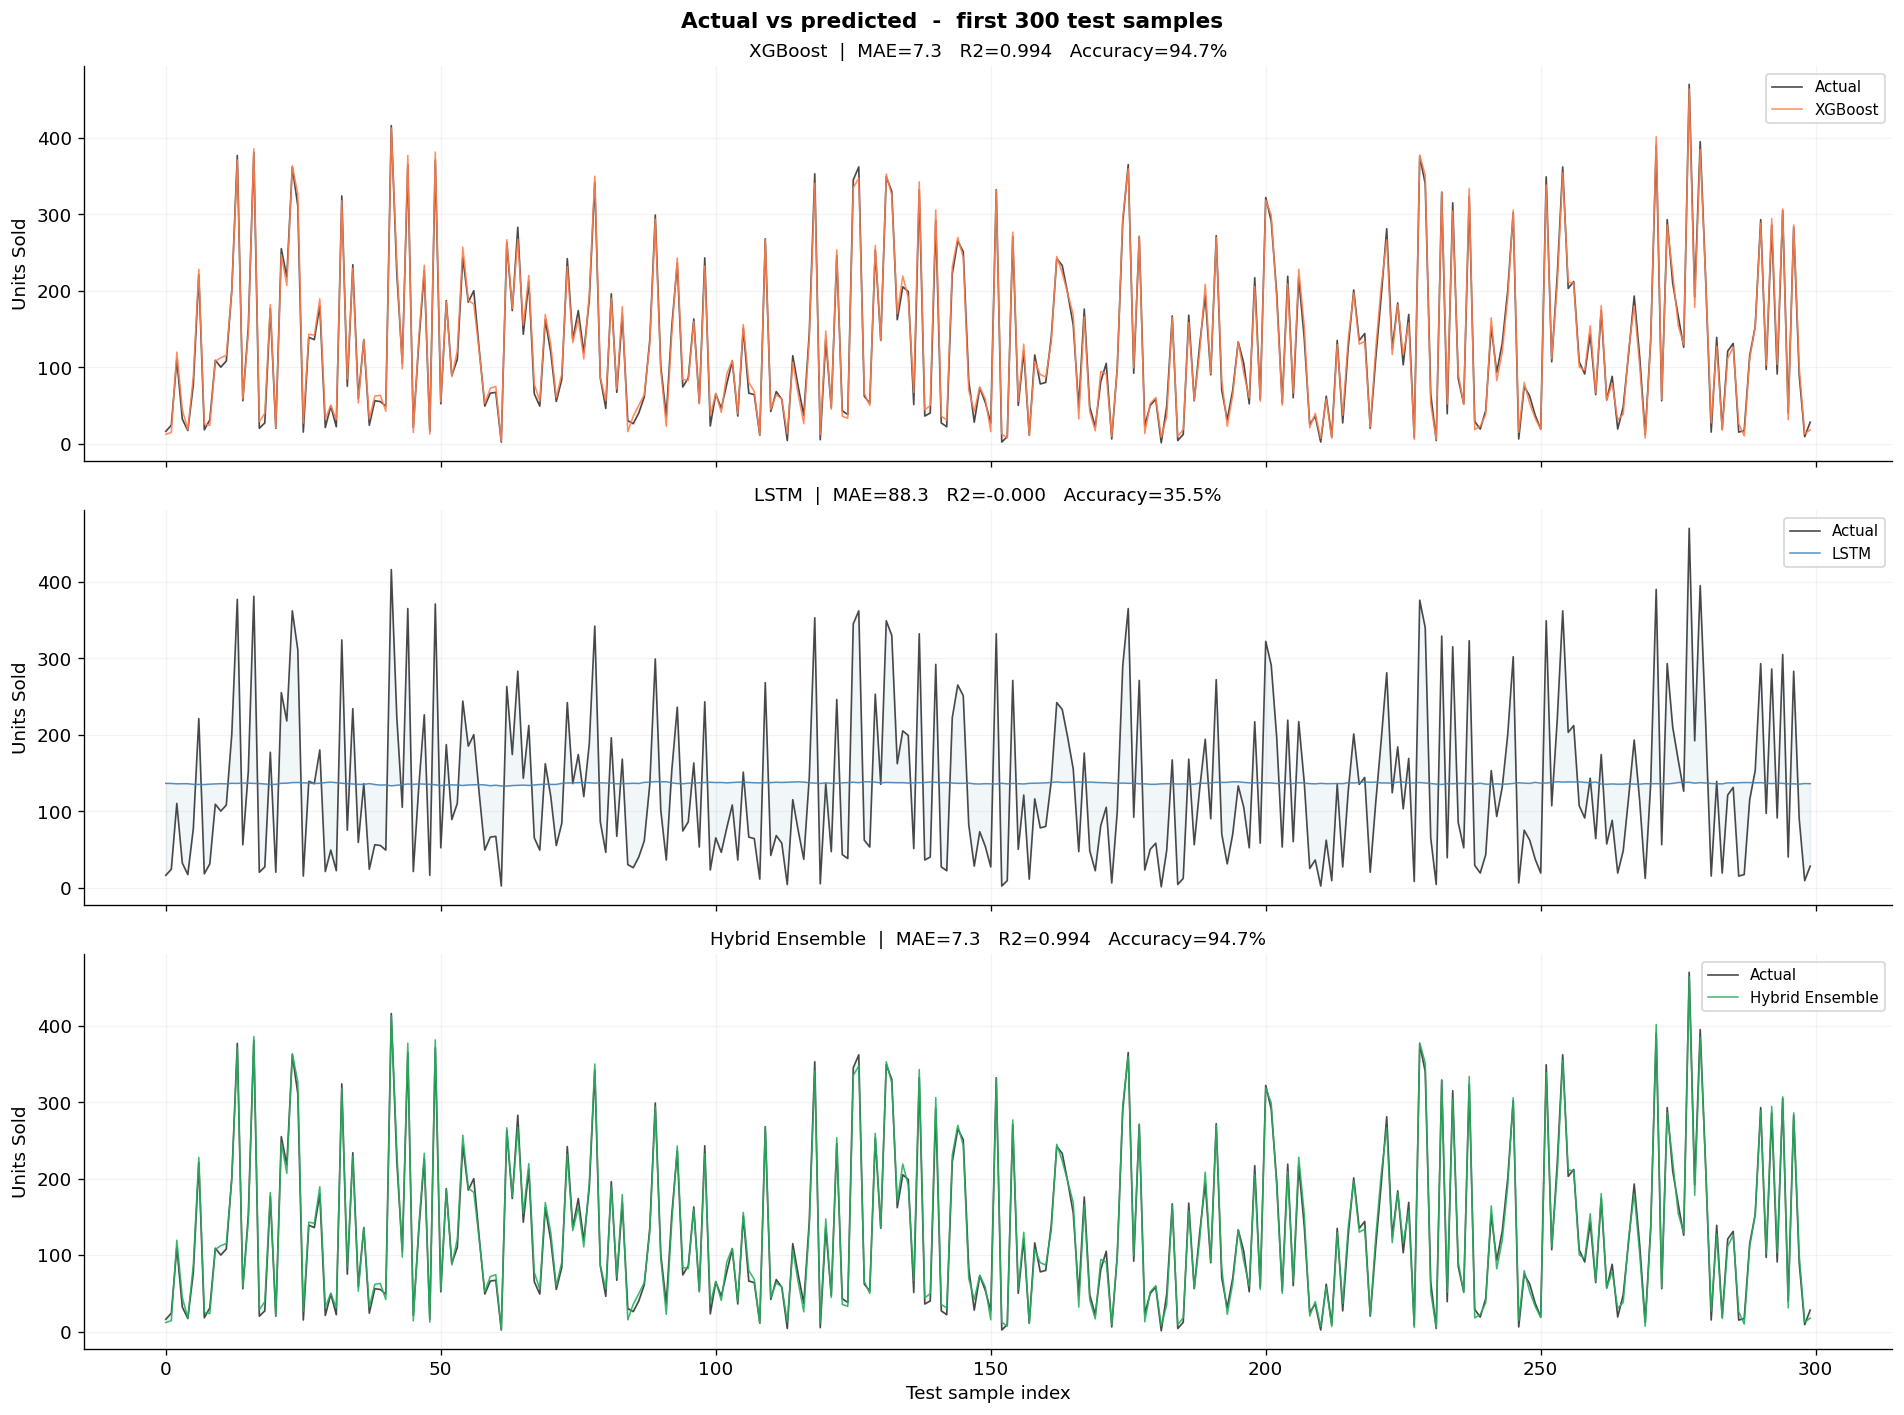

In [101]:
N = min(300, len(y_true))
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Actual vs predicted  -  first 300 test samples',
             fontsize=13, fontweight='bold')

for ax, (name, preds, colour) in zip(axes, [
    ('XGBoost',         xgb_preds,      'coral'),
    ('LSTM',            lstm_preds,     'steelblue'),
    ('Hybrid Ensemble', ensemble_preds, '#27ae60'),
]):
    ax.plot(y_true[:N],  color='black', lw=1.0, label='Actual', alpha=0.7)
    ax.plot(preds[:N],   color=colour,  lw=0.9, label=name,     alpha=0.9)
    ax.fill_between(range(N), y_true[:N], preds[:N], alpha=0.07, color=colour)
    ax.set_title(
        f'{name}  |  MAE={res_df.loc[name,"MAE"]:.1f}   '
        f'R2={res_df.loc[name,"R2"]:.3f}   '
        f'Accuracy={res_df.loc[name,"Accuracy_%"]:.1f}%', fontsize=11)
    ax.set_ylabel('Units Sold'); ax.legend(fontsize=9); ax.grid(alpha=0.15)

axes[-1].set_xlabel('Test sample index')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

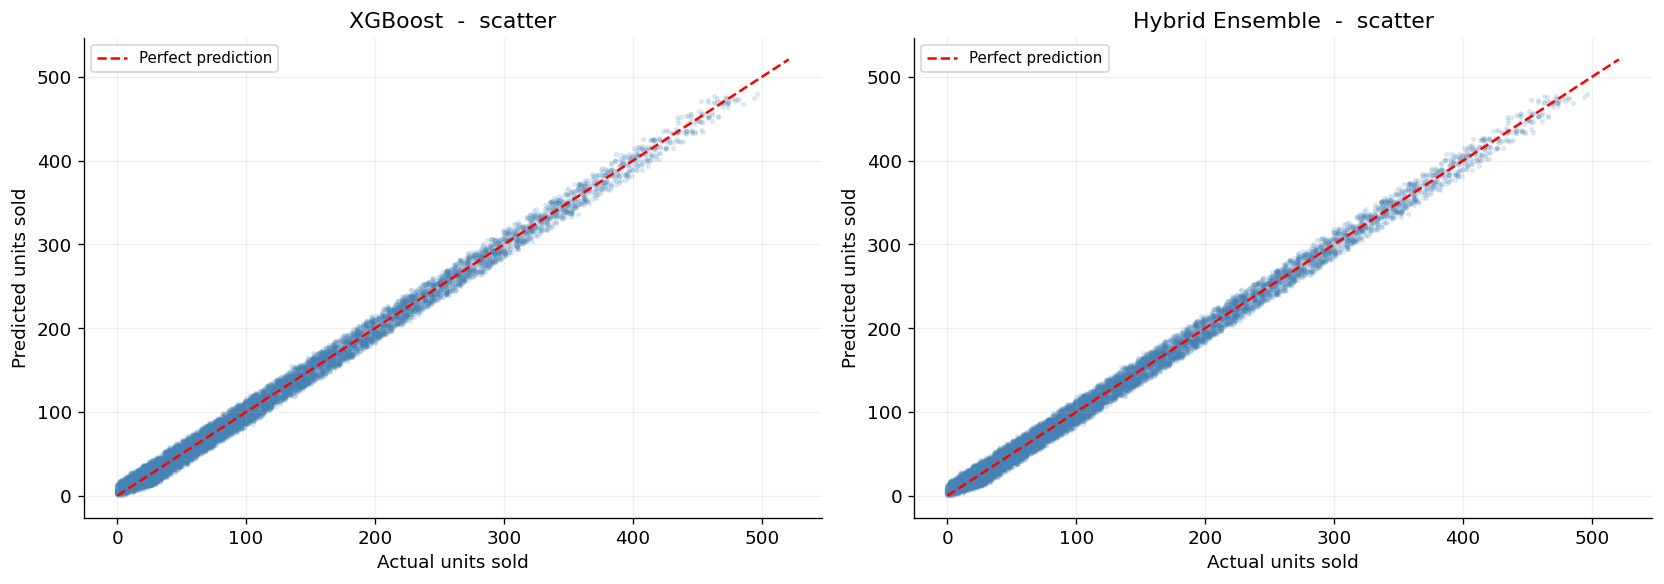

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, preds) in zip(axes, [('XGBoost', xgb_preds), ('Hybrid Ensemble', ensemble_preds)]):
    ax.scatter(y_true, preds, alpha=0.12, s=5, color='steelblue')
    lim = max(y_true.max(), preds.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual units sold'); ax.set_ylabel('Predicted units sold')
    ax.set_title(f'{name}  -  scatter')
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

---
## 13. SHAP Explainability

SHAP TreeExplainer is applied to the XGBoost component. Values show how each feature shifts a prediction away from the model's average output.


In [103]:
print('Computing SHAP values...')
explainer   = shap.TreeExplainer(xgb_model)
N_SHAP      = min(1500, len(X_te_xgb))
shap_values = explainer.shap_values(X_te_xgb[:N_SHAP])
shap_df     = pd.DataFrame(X_te_xgb[:N_SHAP], columns=SELECTED_FEATURES)
print(f'SHAP values computed for {N_SHAP} samples.')

Computing SHAP values...
SHAP values computed for 1500 samples.


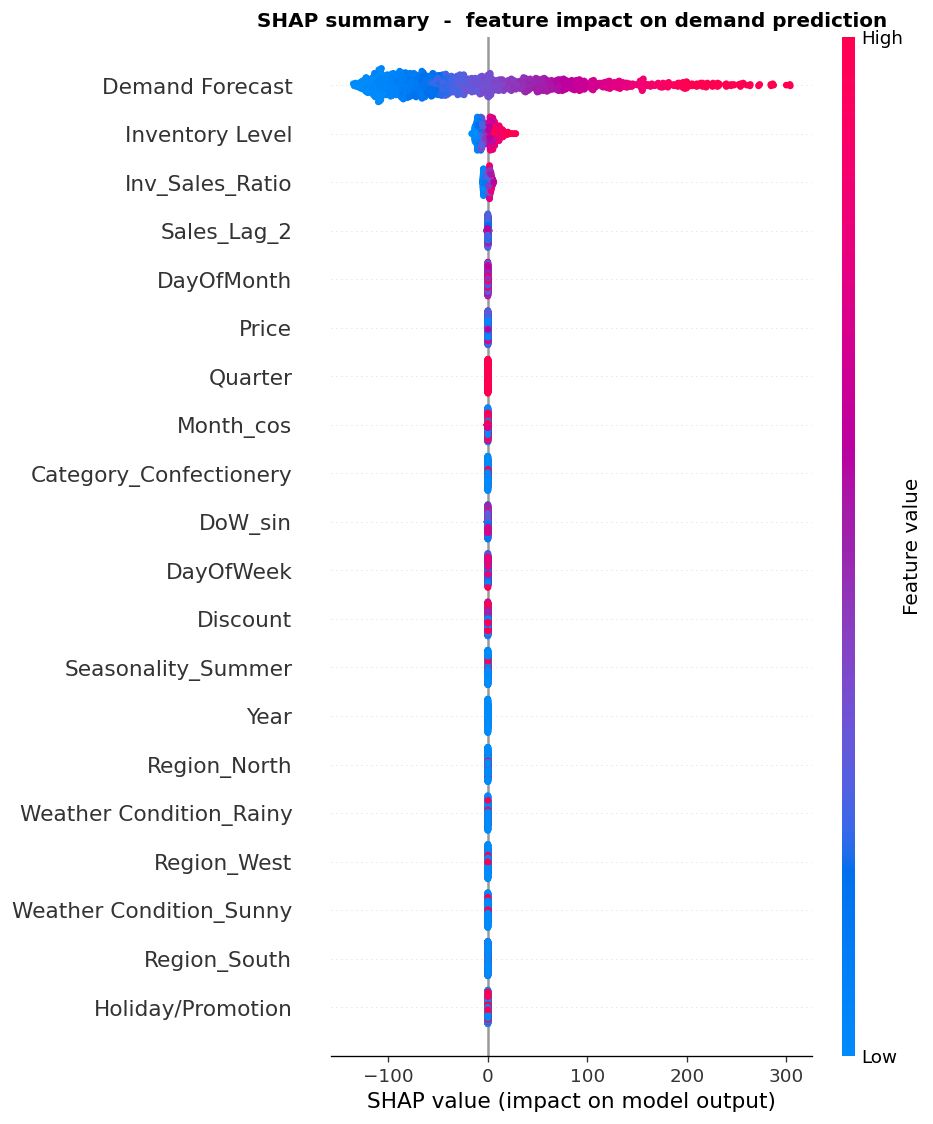

In [104]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, shap_df, plot_type='dot', max_display=20, show=False)
plt.title('SHAP summary  -  feature impact on demand prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

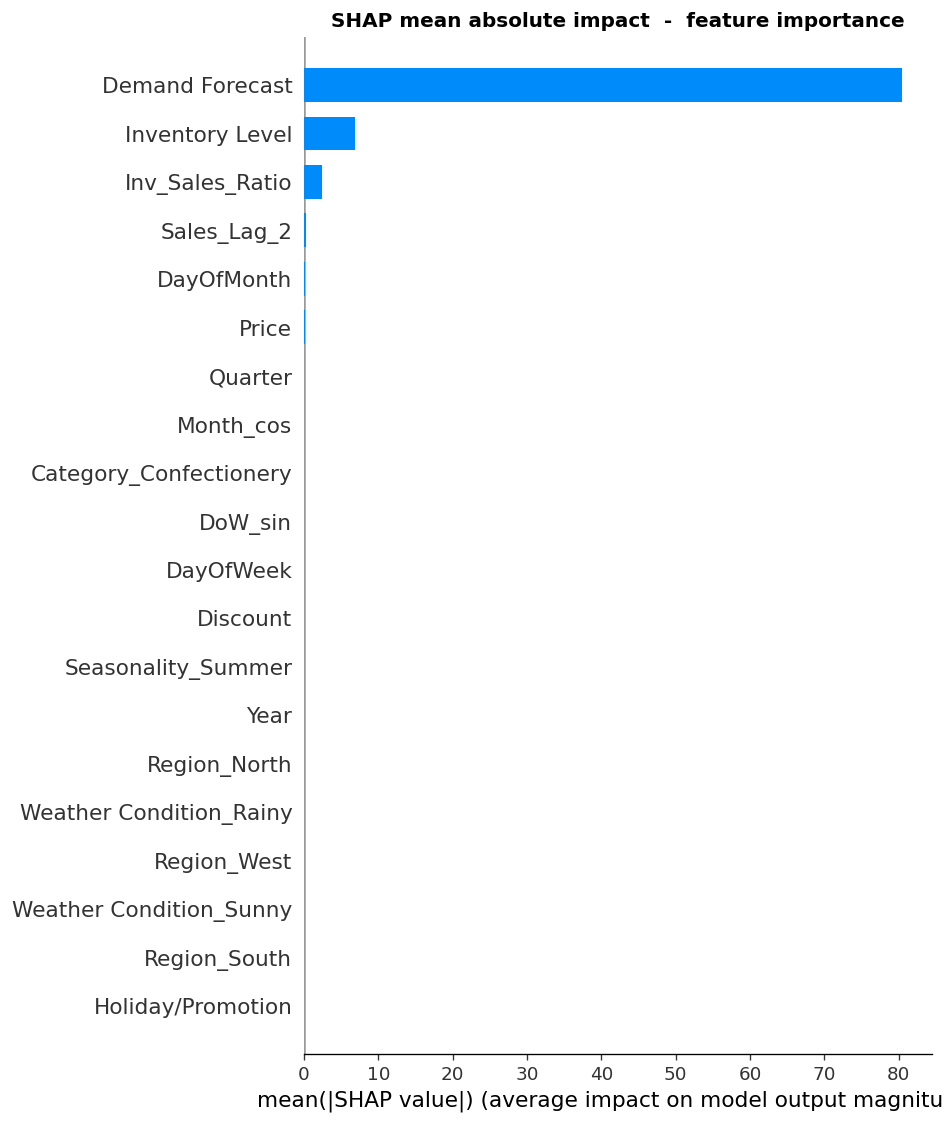

In [105]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, shap_df, plot_type='bar', max_display=20, show=False)
plt.title('SHAP mean absolute impact  -  feature importance',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

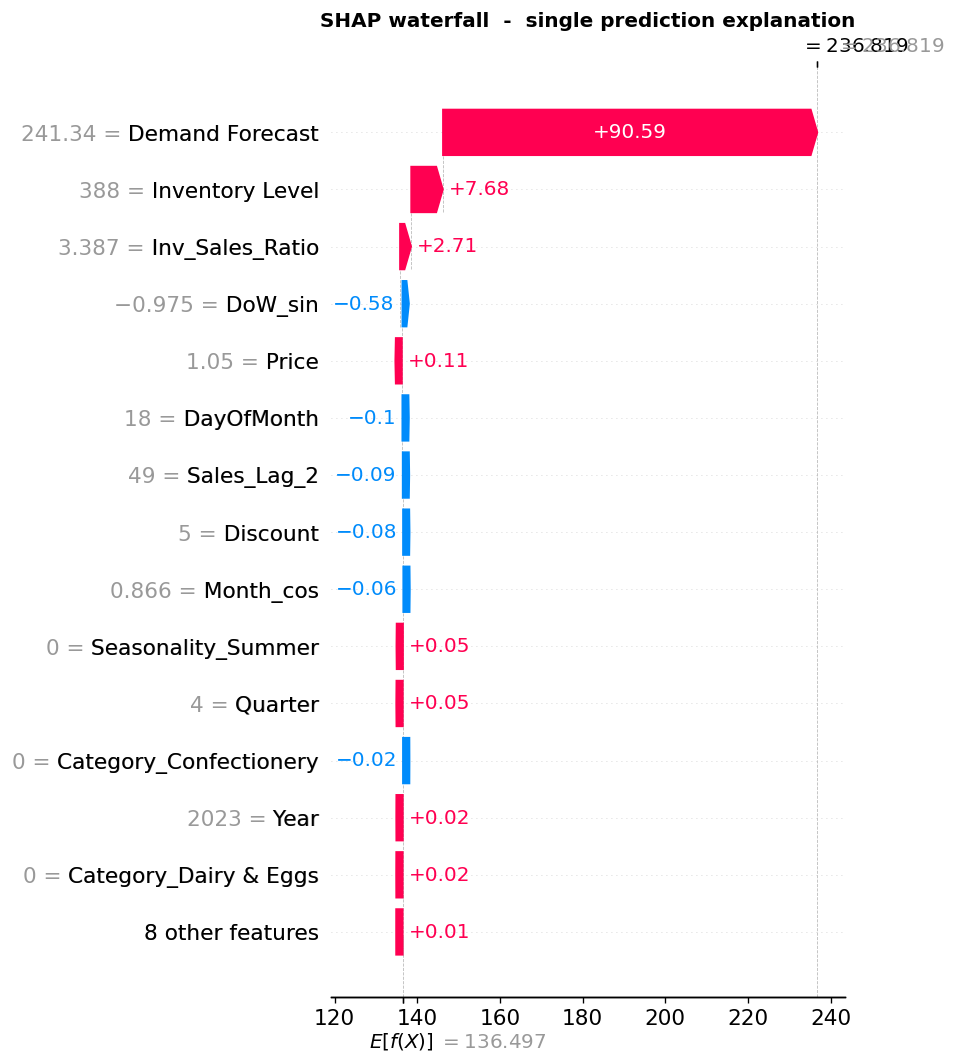

Actual demand     : 223 units
XGBoost predicted : 237 units
Ensemble predicted: 237 units


In [106]:
EXPLAIN_IDX = 42
exp = shap.Explanation(
    values=shap_values[EXPLAIN_IDX],
    base_values=explainer.expected_value,
    data=shap_df.iloc[EXPLAIN_IDX].values,
    feature_names=SELECTED_FEATURES
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(exp, max_display=15, show=False)
plt.title('SHAP waterfall  -  single prediction explanation',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', bbox_inches='tight')
plt.show()
print(f'Actual demand     : {y_test_actual[EXPLAIN_IDX]:.0f} units')
print(f'XGBoost predicted : {xgb_preds[EXPLAIN_IDX]:.0f} units')
print(f'Ensemble predicted: {ensemble_preds[EXPLAIN_IDX]:.0f} units')

---
## 14. Date-Range Forecasting (Recursive)

Forecasts daily demand for any date range using historical demand patterns.

**How it works:** Each day's ensemble prediction becomes the next day's lag feature. The forecaster rolls forward one day at a time.

**Recommended range:** 2022-01-01 to 2024-01-01 for highest accuracy. Short extrapolation up to ~14 days beyond the data end is acceptable.

**Required inputs per forecast:** `from_date`, `to_date`, and business context variables below.


In [107]:
def build_feature_row(date, history_sales, price, discount, inventory_level,
                      weather, region, category, seasonality, holiday_promotion,
                      competitor_pricing=1.0, demand_forecast=None):
    """Construct a single feature vector matching SELECTED_FEATURES exactly.

    All rolling/lag statistics mirror the training-time definitions.
    demand_forecast should be the upstream planning forecast for this date
    when available; if None, falls back to a 7-day rolling average proxy.
    """
    date  = pd.Timestamp(date)
    sales = np.array(history_sales, dtype=float)

    lag   = lambda n: float(sales[-n]) if len(sales) >= n else 0.0
    rmean = lambda w: float(np.mean(sales[-w:])) if len(sales) >= 1 else 0.0
    rstd  = lambda w: float(np.std(sales[-w:]))  if len(sales) >= 2 else 0.0
    rmax  = lambda w: float(np.max(sales[-w:]))  if len(sales) >= 1 else 0.0
    rmin  = lambda w: float(np.min(sales[-w:]))  if len(sales) >= 1 else 0.0

    rm7 = rmean(7)
    dow = date.dayofweek
    mon = date.month
    woy = date.isocalendar()[1]

    if demand_forecast is None:
        demand_forecast = rm7   # rolling average as proxy when upstream forecast unavailable

    # Forecast_Lag_1 and Forecast_Error_Lag_1 use yesterday's forecast and actual
    forecast_lag1 = lag(1)          # yesterday's sales as proxy for yesterday's forecast
    forecast_err  = lag(1) - forecast_lag1

    base = {
        'Demand Forecast'      : demand_forecast,
        'Forecast_Lag_1'       : forecast_lag1,
        'Forecast_Error_Lag_1' : forecast_err,
        'Inventory Level'      : inventory_level,
        'Price'                : price,
        'Discount'             : discount,
        'Holiday/Promotion'    : holiday_promotion,
        'Competitor Pricing'   : competitor_pricing,
        'Sales_Lag_1'          : lag(1),  'Sales_Lag_2'  : lag(2),  'Sales_Lag_3': lag(3),
        'Sales_Lag_7'          : lag(7),  'Sales_Lag_14' : lag(14),
        'RollingMean_3'        : rmean(3), 'RollingMean_7': rm7,
        'RollingMean_14'       : rmean(14),'RollingMean_28': rmean(28),
        'RollingStd_3'         : rstd(3),  'RollingStd_7' : rstd(7),
        'RollingStd_14'        : rstd(14), 'RollingStd_28': rstd(28),
        'RollingMax_7'         : rmax(7),  'RollingMin_7' : rmin(7),
        'Effective_Price'      : price * (1 - discount / 100),
        'Price_vs_Competitor'  : price / (competitor_pricing + 1e-5),
        'Inv_Sales_Ratio'      : min(inventory_level / (rm7 + 1), 50),
        'Discount_x_Price'     : discount * price,
        'DayOfWeek'            : dow,  'DayOfMonth': date.day,  'Month': mon,
        'Quarter'              : date.quarter, 'WeekOfYear': woy,
        'IsWeekend'            : int(dow >= 5), 'Year': date.year,
        'Month_sin': np.sin(2*np.pi*mon/12), 'Month_cos': np.cos(2*np.pi*mon/12),
        'DoW_sin'  : np.sin(2*np.pi*dow/7),  'DoW_cos'  : np.cos(2*np.pi*dow/7),
        'WoY_sin'  : np.sin(2*np.pi*woy/52), 'WoY_cos'  : np.cos(2*np.pi*woy/52),
    }

    nominal_input = pd.DataFrame([{
        'Weather Condition': weather, 'Region': region,
        'Category': category, 'Seasonality': seasonality
    }])[NOMINAL]
    ohe_row = ohe.transform(nominal_input.astype(str))[0]
    ohe_map = dict(zip(ohe.get_feature_names_out(NOMINAL), ohe_row))

    combined = {**base, **ohe_map}
    return np.array([combined.get(f, 0.0) for f in SELECTED_FEATURES], dtype=float)

print('Feature row builder ready.')

Feature row builder ready.


In [108]:
def forecast_date_range(from_date, to_date, price, discount, inventory_level,
                        weather='Sunny', region='North', category='Drinks',
                        seasonality='Summer', holiday_promotion=0,
                        competitor_pricing=1.0, demand_forecast=None,
                        seed_store='S001', seed_product='PROD-001'):
    """Recursive daily forecaster.

    Each day's ensemble prediction feeds back as lag features for the next day.
    seed_store / seed_product specify which entity's recent history seeds the window.
    """
    # Input validation
    from_date = pd.Timestamp(from_date)
    to_date   = pd.Timestamp(to_date)
    if to_date < from_date:
        raise ValueError('to_date must be >= from_date')
    if discount < 0 or discount > 100:
        raise ValueError('discount must be between 0 and 100')
    if price <= 0:
        raise ValueError('price must be positive')

    date_range = pd.date_range(start=from_date, end=to_date, freq='D')

    seed_hist = (df[(df['Store ID'] == seed_store) & (df['Product ID'] == seed_product)]
                 .sort_values('Date').tail(60)['Units Sold'].tolist())
    if len(seed_hist) < SEQ_LEN:
        raise ValueError(f'Need at least {SEQ_LEN} seed rows, got {len(seed_hist)}. '
                         f'Check seed_store and seed_product.')

    rolling_sales = list(seed_hist)

    seed_rows = []
    for i in range(SEQ_LEN):
        r = build_feature_row(
            date=from_date - pd.Timedelta(days=SEQ_LEN - i),
            history_sales=seed_hist[:max(1, len(seed_hist) - SEQ_LEN + i)],
            price=price, discount=discount, inventory_level=inventory_level,
            weather=weather, region=region, category=category,
            seasonality=seasonality, holiday_promotion=holiday_promotion,
            competitor_pricing=competitor_pricing, demand_forecast=demand_forecast)
        seed_rows.append(r)

    lstm_window = list(lstm_feat_scaler.transform(np.array(seed_rows)))
    records = []

    for forecast_date in date_range:
        feat_raw = build_feature_row(
            date=forecast_date, history_sales=rolling_sales,
            price=price, discount=discount, inventory_level=inventory_level,
            weather=weather, region=region, category=category,
            seasonality=seasonality, holiday_promotion=holiday_promotion,
            competitor_pricing=competitor_pricing, demand_forecast=demand_forecast)

        xgb_p = float(np.clip(xgb_model.predict(feat_raw.reshape(1, -1))[0], 0, None))

        feat_sc = lstm_feat_scaler.transform(feat_raw.reshape(1, -1))[0]
        lstm_window.append(feat_sc)
        lstm_window = lstm_window[-SEQ_LEN:]
        lstm_sc_p   = lstm_model.predict(
            np.array(lstm_window).reshape(1, SEQ_LEN, -1), verbose=0)[0, 0]
        lstm_p = float(np.clip(
            target_scaler.inverse_transform([[lstm_sc_p]])[0, 0], 0, None))

        ens_p = float(np.clip(
            meta_learner.predict([[lstm_p, xgb_p]])[0], 0, None))

        records.append({
            'Date'              : forecast_date,
            'Day'               : forecast_date.strftime('%A'),
            'IsWeekend'         : int(forecast_date.dayofweek >= 5),
            'LSTM_Forecast'     : round(lstm_p, 1),
            'XGBoost_Forecast'  : round(xgb_p, 1),
            'Ensemble_Forecast' : round(ens_p, 1),
        })
        rolling_sales.append(ens_p)
        rolling_sales = rolling_sales[-60:]

    return pd.DataFrame(records)

print('Recursive forecaster ready.')

Recursive forecaster ready.


In [109]:
# ── Configure test forecast here ──────────────────────────────────────────────
FROM_DATE       = '2023-11-01'
TO_DATE         = '2023-11-30'
PRICE           = 0.85
DISCOUNT        = 10
INVENTORY       = 300
WEATHER         = 'Rainy'    # Sunny / Rainy / Cloudy / Snowy
REGION          = 'North'    # North / South / East / West
CATEGORY        = 'Drinks'   # Drinks / Snacks / Confectionery / Bakery & Bread / Dairy & Eggs / Grocery
SEASONALITY     = 'Autumn'   # Spring / Summer / Autumn / Winter
HOLIDAY         = 0          # 0 or 1
DEMAND_FORECAST = None       # float (e.g. 120.0) if upstream forecast available; None = rolling mean fallback
# ─────────────────────────────────────────────────────────────────────────────

forecast_df = forecast_date_range(
    from_date=FROM_DATE, to_date=TO_DATE,
    price=PRICE, discount=DISCOUNT, inventory_level=INVENTORY,
    weather=WEATHER, region=REGION, category=CATEGORY,
    seasonality=SEASONALITY, holiday_promotion=HOLIDAY,
    demand_forecast=DEMAND_FORECAST,
)

print(f'Forecast  {FROM_DATE}  to  {TO_DATE}')
print()
print(forecast_df.to_string(index=False))

Forecast  2023-11-01  to  2023-11-30

      Date       Day  IsWeekend  LSTM_Forecast  XGBoost_Forecast  Ensemble_Forecast
2023-11-01 Wednesday          0          136.2              77.3               77.1
2023-11-02  Thursday          0          135.6              82.6               82.3
2023-11-03    Friday          0          135.4              66.7               66.4
2023-11-04  Saturday          1          135.2              66.3               66.0
2023-11-05    Sunday          1          134.9              50.9               50.5
2023-11-06    Monday          0          135.0              54.4               54.0
2023-11-07   Tuesday          0          134.6              57.6               57.2
2023-11-08 Wednesday          0          134.2              59.3               58.9
2023-11-09  Thursday          0          134.0              57.8               57.3
2023-11-10    Friday          0          134.2              54.7               54.3
2023-11-11  Saturday          1       

In [110]:
total = forecast_df['Ensemble_Forecast'].sum()
avg   = forecast_df['Ensemble_Forecast'].mean()
peak  = forecast_df.loc[forecast_df['Ensemble_Forecast'].idxmax()]
low   = forecast_df.loc[forecast_df['Ensemble_Forecast'].idxmin()]
wknd  = forecast_df[forecast_df['IsWeekend']==1]['Ensemble_Forecast'].mean()
wkday = forecast_df[forecast_df['IsWeekend']==0]['Ensemble_Forecast'].mean()

print('=' * 54)
print(f'  FORECAST SUMMARY  {FROM_DATE}  to  {TO_DATE}')
print('=' * 54)
print(f'  Total demand forecast  : {total:,.0f} units')
print(f'  Daily average          : {avg:.1f} units')
print(f'  Peak day   : {peak["Date"].date()} ({peak["Day"]})  -  {peak["Ensemble_Forecast"]:.0f} units')
print(f'  Lowest day : {low["Date"].date()} ({low["Day"]})  -  {low["Ensemble_Forecast"]:.0f} units')
print(f'  Avg weekend demand     : {wknd:.1f} units')
print(f'  Avg weekday demand     : {wkday:.1f} units')
print('=' * 54)

  FORECAST SUMMARY  2023-11-01  to  2023-11-30
  Total demand forecast  : 1,296 units
  Daily average          : 43.2 units
  Peak day   : 2023-11-02 (Thursday)  -  82 units
  Lowest day : 2023-11-30 (Thursday)  -  17 units
  Avg weekend demand     : 42.4 units
  Avg weekday demand     : 43.5 units


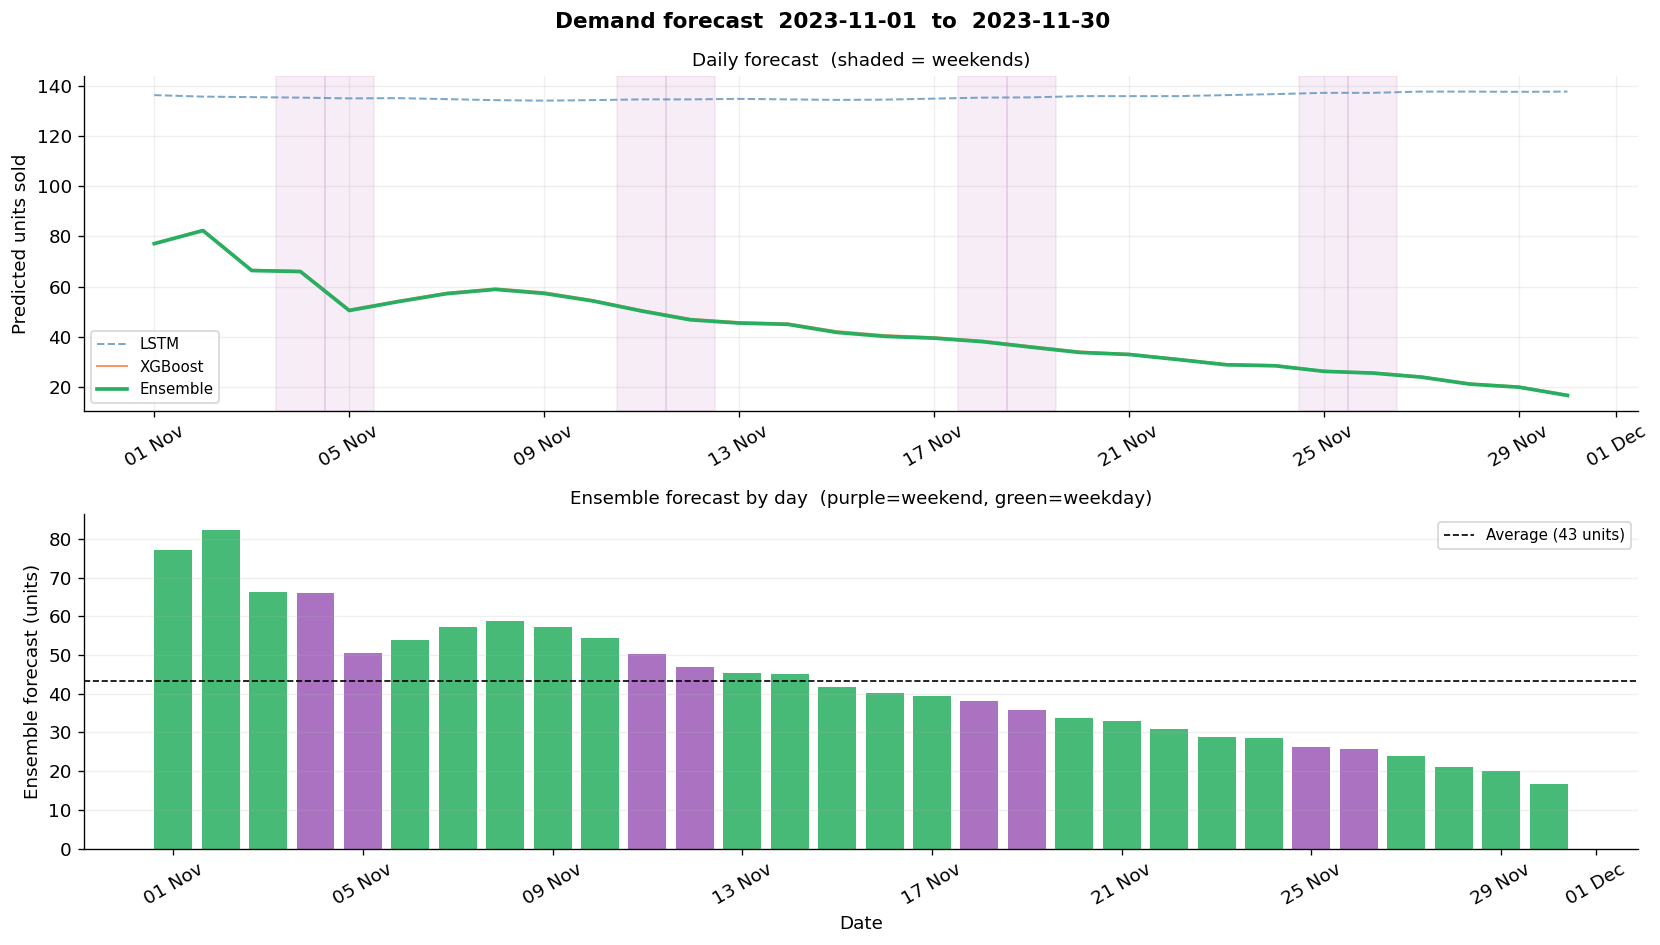

Forecast saved: forecast_2023-11-01_2023-11-30.csv


In [111]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(f'Demand forecast  {FROM_DATE}  to  {TO_DATE}',
             fontsize=13, fontweight='bold')

axes[0].plot(forecast_df['Date'], forecast_df['LSTM_Forecast'],
             label='LSTM', color='steelblue', lw=1.2, linestyle='--', alpha=0.7)
axes[0].plot(forecast_df['Date'], forecast_df['XGBoost_Forecast'],
             label='XGBoost', color='coral', lw=1.2, alpha=0.85)
axes[0].plot(forecast_df['Date'], forecast_df['Ensemble_Forecast'],
             label='Ensemble', color='#27ae60', lw=2.2)
for _, row in forecast_df[forecast_df['IsWeekend']==1].iterrows():
    axes[0].axvspan(row['Date'] - pd.Timedelta(hours=12),
                    row['Date'] + pd.Timedelta(hours=12),
                    alpha=0.07, color='purple')
axes[0].set_ylabel('Predicted units sold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_title('Daily forecast  (shaded = weekends)', fontsize=11)

bar_colors = ['#9b59b6' if w else '#27ae60' for w in forecast_df['IsWeekend']]
axes[1].bar(forecast_df['Date'], forecast_df['Ensemble_Forecast'],
            color=bar_colors, width=0.8, alpha=0.85)
axes[1].axhline(avg, color='black', linestyle='--', lw=1, label=f'Average ({avg:.0f} units)')
axes[1].set_ylabel('Ensemble forecast (units)')
axes[1].set_xlabel('Date')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.2)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_title('Ensemble forecast by day  (purple=weekend, green=weekday)', fontsize=11)

plt.tight_layout()
plt.savefig('forecast_output.png', bbox_inches='tight')
plt.show()

csv_name = f'forecast_{FROM_DATE}_{TO_DATE}.csv'
forecast_df.to_csv(csv_name, index=False)
print(f'Forecast saved: {csv_name}')

---
## 15. Save Artefacts

In [112]:
SAVE_DIR = 'saved_models'
os.makedirs(SAVE_DIR, exist_ok=True)

lstm_model.save(f'{SAVE_DIR}/lstm_model.keras')
joblib.dump(xgb_model,       f'{SAVE_DIR}/xgb_model.pkl')
joblib.dump(meta_learner,    f'{SAVE_DIR}/meta_learner.pkl')
joblib.dump(lstm_feat_scaler,f'{SAVE_DIR}/lstm_feature_scaler.pkl')
joblib.dump(target_scaler,   f'{SAVE_DIR}/target_scaler.pkl')
joblib.dump(le_store,        f'{SAVE_DIR}/le_store.pkl')
joblib.dump(le_product,      f'{SAVE_DIR}/le_product.pkl')
joblib.dump(ohe,             f'{SAVE_DIR}/ohe_encoder.pkl')
joblib.dump({
    'SELECTED_FEATURES' : SELECTED_FEATURES,
    'NOMINAL'           : NOMINAL,
    'SEQ_LEN'           : SEQ_LEN,
    'TARGET'            : TARGET,
    'SEED'              : SEED,
}, f'{SAVE_DIR}/config.pkl')

print(f'Artefacts saved to ./{SAVE_DIR}/')
print()
for fname in sorted(os.listdir(SAVE_DIR)):
    kb = os.path.getsize(os.path.join(SAVE_DIR, fname)) / 1024
    print(f'  {fname:<35} {kb:>8.1f} KB')

Artefacts saved to ./saved_models/

  config.pkl                               0.5 KB
  le_product.pkl                           0.7 KB
  le_store.pkl                             0.5 KB
  lstm_feature_scaler.pkl                  1.5 KB
  lstm_model.keras                      1621.8 KB
  meta_learner.pkl                         0.5 KB
  ohe_encoder.pkl                          2.1 KB
  target_scaler.pkl                        0.7 KB
  xgb_model.pkl                         1647.2 KB


In [113]:
# Download artefacts — works in Google Colab; skipped automatically elsewhere
try:
    from google.colab import files
    for fname in sorted(os.listdir(SAVE_DIR)):
        fpath = os.path.join(SAVE_DIR, fname)
        files.download(fpath)
        print(f'Downloaded : {fpath}')
except ImportError:
    print('Not running in Colab — artefacts available in:', SAVE_DIR)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded : saved_models/config.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded : saved_models/target_scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded : saved_models/xgb_model.pkl
